In [1]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
import numpy as np
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input

In [2]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 50
IMAGES_PATH = "/Volumes/T9/HAM10000"
CSV_PATH = "/Volumes/T9/HAM10000_metadata.csv"
df = pd.read_csv("/Volumes/T9/HAM10000_metadata.csv")
# Définition des classes à conserver
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

In [3]:

# 📁 Mapping des chemins images dans une nouvelle colonne 'path'
df['path'] = df['image_id'].apply(lambda x: os.path.join(IMAGES_PATH, f"{x}.jpg"))

# 🏷️ Label to index mapping
label_to_index = {v: k for k, v in CLASS_LABELS.items()}
df = df[df['dx'].isin(CLASS_LABELS.values())]
df['label'] = df['dx'].map(label_to_index)


In [4]:
import os
import shutil
from sklearn.model_selection import train_test_split
import pandas as pd

# === 0. Paramètres ===
DATASET_DIR = '/Volumes/T9/HAM10000'  # répertoire contenant toutes les images originales
SAVE_DIR = '/Volumes/T9/HAM10000/data_split'  # répertoire cible pour sauvegarde
os.makedirs(SAVE_DIR, exist_ok=True)

# === 1. Split en 70% train, 15% val, 15% test ===
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

# Conversion des labels en str (requis pour Keras et ImageDataGenerator)
for subset in [train_df, val_df, test_df]:
    subset['label'] = subset['label'].astype(str)



In [5]:
# === 2. Sauvegarde des DataFrames en CSV pour traçabilité future ===
train_df.to_csv(os.path.join(SAVE_DIR, 'train_labels.csv'), index=False)
val_df.to_csv(os.path.join(SAVE_DIR, 'val_labels.csv'), index=False)
test_df.to_csv(os.path.join(SAVE_DIR, 'test_labels.csv'), index=False)

# === 3. Copie physique des images ===
def save_images_from_df(df, subset_name):
    subset_dir = os.path.join(SAVE_DIR, subset_name)
    os.makedirs(subset_dir, exist_ok=True)
    
    for _, row in df.iterrows():
        image_filename = row['image_id']  # ou 'image' si c'est la colonne dans ton CSV
        possible_extensions = ['.jpg', '.jpeg', '.png']
        
        # Trouver le fichier existant avec une des extensions
        for ext in possible_extensions:
            test_path = os.path.join(DATASET_DIR, image_filename + ext)
            if os.path.exists(test_path):
                src_path = test_path
                break
        else:
            print(f"[⚠️] Image introuvable : {image_filename}")
            continue

        class_dir = os.path.join(subset_dir, row['label'])
        os.makedirs(class_dir, exist_ok=True)
        dst_path = os.path.join(class_dir, os.path.basename(src_path))
        shutil.copy2(src_path, dst_path)


save_images_from_df(train_df, 'train')
save_images_from_df(val_df, 'val')
save_images_from_df(test_df, 'test')


KeyboardInterrupt: 

In [17]:
def print_class_distribution(df, name="Dataset"):
    print(f"\n📊 Répartition dans {name} :")
    dist = df['label'].value_counts().sort_index()
    for i, count in dist.items():
        print(f"{CLASS_LABELS[int(i)]:<6} : {count}")

print_class_distribution(train_df, "Train")
print_class_distribution(val_df, "Validation")
print_class_distribution(test_df, "Test")


📊 Répartition dans Train :
akiec  : 262
bcc    : 411
bkl    : 879
df     : 92
nv     : 5364
vasc   : 114
mel    : 890

📊 Répartition dans Validation :
akiec  : 33
bcc    : 51
bkl    : 110
df     : 12
nv     : 670
vasc   : 14
mel    : 111

📊 Répartition dans Test :
akiec  : 32
bcc    : 52
bkl    : 110
df     : 11
nv     : 671
vasc   : 14
mel    : 112


In [5]:
# Facteurs de sampling (uniquement pour train)
sampling_factors = {
    0: 3,    # akiec
    1: 1,     # bcc
    2: 1,   # bkl
    3: 6,    # df
    4: 1,  # nv
    5: 1,    # vasc
    6: 2.5   # mel
}

# Vérification des répartitions
def print_class_distribution(df, name="Dataset"):
    dist = df['label'].value_counts().sort_index()
    print(f"\n📊 Répartition des classes dans {name} :")
    for i, count in dist.items():
        class_name = CLASS_LABELS[int(i)]
        print(f"{class_name:<6} : {count}")

print_class_distribution(train_df, "Train")
print_class_distribution(val_df, "Validation")
print_class_distribution(test_df, "Test Interne")

def resample_dataframe(df, factors):
    resampled_df = []

    for label, factor in factors.items():
        subset = df[df['label'] == str(label)]
        n_samples = int(len(subset) * factor)

        if factor > 1:
            duplicated = pd.concat([subset] * int(factor), ignore_index=True)
            remainder = int((factor % 1) * len(subset))
            if remainder > 0:
                duplicated = pd.concat([duplicated, subset.sample(n=remainder, replace=True, random_state=42)], ignore_index=True)
        elif factor < 1:
            duplicated = subset.sample(n=n_samples, random_state=42)
        else:
            duplicated = subset

        resampled_df.append(duplicated)

    return pd.concat(resampled_df, ignore_index=True).sample(frac=1, random_state=42)

# ➕ Application du resampling uniquement sur le train
train_df_balanced = resample_dataframe(train_df, sampling_factors)

# 🔍 Vérification finale
print_class_distribution(train_df_balanced, "Train (Resampled)")



📊 Répartition des classes dans Train :
akiec  : 262
bcc    : 411
bkl    : 879
df     : 92
nv     : 5364
vasc   : 114
mel    : 890

📊 Répartition des classes dans Validation :
akiec  : 33
bcc    : 51
bkl    : 110
df     : 12
nv     : 670
vasc   : 14
mel    : 111

📊 Répartition des classes dans Test Interne :
akiec  : 32
bcc    : 52
bkl    : 110
df     : 11
nv     : 671
vasc   : 14
mel    : 112

📊 Répartition des classes dans Train (Resampled) :
akiec  : 786
bcc    : 411
bkl    : 879
df     : 552
nv     : 5364
vasc   : 114
mel    : 2225


In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import Sequence
import tensorflow as tf
# Définition des classes rares (indices int)
RARE_CLASSES = [0]  # akiec, df, vasc, mel

# Séparation des dataframes en classes rares et communes
df_rare = train_df[train_df['label'].astype(int).isin(RARE_CLASSES)]
df_common = train_df[~train_df['label'].astype(int).isin(RARE_CLASSES)]

# Liste complète des classes en str (pour forcer la même encodage one-hot)
all_classes = sorted(train_df['label'].astype(str).unique())


# Augmentation douce pour classes communes
common_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=35,
    zoom_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    shear_range=0.05,
    vertical_flip=False,
    brightness_range=[0.8, 1.2],
    fill_mode='reflect',
    channel_shift_range=10.0,

)

# Augmentation forte pour classes rares
rare_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=60,                # rotations réalistes sans tout retourner
    zoom_range=[0.8, 1.2],                   # léger zoom in/out
    width_shift_range=0.15,          # petits déplacements
    height_shift_range=0.15,
    horizontal_flip=True,            # miroir ok
    vertical_flip=False,             # généralement pas réaliste en dermato
    shear_range=0.1,                  # légère déformation
    brightness_range=[0.80, 1.2],   # variations douces d’éclairage
    channel_shift_range=10.0,        # petit ajustement des couleurs
    fill_mode='reflect',
 
)

# Générateurs pour classes communes et rares avec classes fixes
common_gen = common_aug.flow_from_dataframe(
    df_common,
    x_col='path',
    y_col='label',
    class_mode='categorical',
    classes=all_classes,
    target_size=(299, 299),
    batch_size=32,
    shuffle=True,
    dtype='float32'
)

rare_gen = rare_aug.flow_from_dataframe(
    df_rare,
    x_col='path',
    y_col='label',
    class_mode='categorical',
    classes=all_classes,
    target_size=(299, 299),
    batch_size=32,
    shuffle=True,
    dtype='float32'
)

# Générateur combiné avec batch_size constant
class CombinedGenerator(Sequence):
    def __init__(self, gen1, gen2, batch_size):
        self.gen1 = gen1
        self.gen2 = gen2
        self.batch_size = batch_size
        self.half_batch = batch_size // 2

    def __len__(self):
        return max(len(self.gen1), len(self.gen2))

    def __getitem__(self, index):
        x1, y1 = self.gen1[index % len(self.gen1)]
        x2, y2 = self.gen2[index % len(self.gen2)]

        # Sous-échantillonnage si batch trop grand
        if x1.shape[0] > self.half_batch:
            idx = tf.random.shuffle(tf.range(x1.shape[0]))[:self.half_batch]
            x1, y1 = tf.gather(x1, idx), tf.gather(y1, idx)

        if x2.shape[0] > self.half_batch:
            idx = tf.random.shuffle(tf.range(x2.shape[0]))[:self.half_batch]
            x2, y2 = tf.gather(x2, idx), tf.gather(y2, idx)

        x = tf.concat([x1, x2], axis=0)
        y = tf.concat([y1, y2], axis=0)
        return x, y

# Instanciation du générateur combiné
train_generator = CombinedGenerator(common_gen, rare_gen, batch_size=32)

# Accès au premier batch (correct pour Sequence)
images, labels = train_generator[0]

# Affichage min et max avec tf.reduce_min/max et numpy()
images_min = tf.reduce_min(images).numpy()
images_max = tf.reduce_max(images).numpy()

print(f"Nouvelle plage des pixels : {images_min} {images_max}")
print(f"Taille du batch images : {images.shape}, labels : {labels.shape}")


Found 7750 validated image filenames belonging to 7 classes.
Found 262 validated image filenames belonging to 7 classes.
Nouvelle plage des pixels : -1.0 1.0
Taille du batch images : (32, 299, 299, 3), labels : (32, 7)


In [21]:
# Liste complète des classes en str (pour forcer la même encodage one-hot)
all_classes = sorted(train_df['label'].astype(str).unique())

from tensorflow.keras.preprocessing.image import ImageDataGenerator
# --- 🔍 Pas d'augmentation pour validation / test ---
val_test_datagen = ImageDataGenerator(
          preprocessing_function=preprocess_input 
)
# --- 🎯 Validation generator ---
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=all_classes
)

# --- 🧪 Test generator ---
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    classes=all_classes
)

Found 1001 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.


In [6]:
# 🔁 Conversion des labels en string
train_df['label'] = train_df['label'].astype(str)
val_df['label'] = val_df['label'].astype(str)
test_df['label'] = test_df['label'].astype(str)
train_df_balanced['label'] = train_df_balanced['label'].astype(str)

In [7]:
# Poids alpha spécifiques pour classes déséquilibrées
alpha = [
    20,  # AKIEC
    2,  # BCC
    1,  # BKL
    7,  # DF
    1,  # NV
    1,  # VASC
    7  # MEL
]

import tensorflow as tf

def focal_loss(alpha, gamma=1):
    alpha_tensor = tf.constant(alpha, dtype=tf.float32)

    @tf.function
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1.0 - 1e-7)

        # Probabilité de la vraie classe
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)

        # Cross-entropy
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        # Focal weight
        focal_weight = tf.pow(1.0 - p_t, gamma)

        # Alpha weight
        alpha_t = tf.reduce_sum(alpha_tensor * y_true, axis=-1)

        return tf.reduce_mean(alpha_t * focal_weight * ce)

    return loss


In [8]:
import tensorflow as tf
from tensorflow.keras import backend as K

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.metrics import Recall, Precision, AUC
from tensorflow.keras import mixed_precision


# ⚙️ Politique de précision mixte
mixed_precision.set_global_policy('mixed_float16')



In [24]:

import tensorflow as tf

def focal_loss(alpha=None, gamma=3.5):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1. - 1e-7)

        if alpha is not None:
            alpha_tensor = tf.constant(alpha, dtype=tf.float32)
            alpha_factor = tf.reduce_sum(y_true * alpha_tensor, axis=-1)
        else:
            alpha_factor = tf.ones(tf.shape(y_true)[0], dtype=tf.float32)

        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)
        focal_factor = tf.pow(1. - p_t, gamma)
        ce = -tf.reduce_sum(y_true * tf.math.log(y_pred), axis=-1)

        return tf.reduce_mean(alpha_factor * focal_factor * ce)

    return loss


In [11]:
import tensorflow as tf

from tensorflow.keras.models import Model
# Importations manquantes ajoutées
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D, Dropout, GlobalMaxPooling2D, BatchNormalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras import mixed_precision, layers 
from tensorflow.keras.activations import swish
from tensorflow.keras.layers import Concatenate

# === 1. Politique Mixed Precision ===
mixed_precision.set_global_policy('mixed_float16')

# === 1. Paramètres ===

N_CLASSES = 7

# === 3. Construction du modèle ===

base_model = Xception(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

base_model.trainable = False
#for layer in base_model.layers:
    #layer.trainable = True

x = base_model.output

# Simple mais efficace
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='swish')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)  # Juste un peu plus de dropout qu'avant


output = Dense(N_CLASSES, activation='softmax', dtype='float32')(x)

model = Model(inputs=base_model.input, outputs=output)

# === 4. Compilation ===
optimizer = AdamW(learning_rate=1e-3)



In [12]:
class_names = sorted(train_df['label'].unique().tolist())

In [13]:
class_names 

['0', '1', '2', '3', '4', '5', '6']

In [9]:
class_names = sorted(train_df['label'].unique().tolist())
class_names

['0', '1', '2', '3', '4', '5', '6']

In [10]:
class_names = sorted(train_df_balanced['label'].unique().tolist())

In [10]:
#code corrigé targetAugment
# Assure-toi que train_df est bien chargé
class_names = sorted(train_df_balanced['label'].unique().tolist())

import tensorflow as tf
import tensorflow_probability as tfp

class TargetedAugmentDataset:
    def __init__(self, dataframe, img_size, class_names, batch_size=32, augment=True):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.class_names = list(class_names)
        self.batch_size = batch_size
        self.augment = augment
        self.strong_aug_classes = tf.constant(['mel', 'akiec'], dtype=tf.string)

        # Table de lookup pour l'encodage des labels
        self.label_lookup = tf.lookup.StaticHashTable(
            tf.lookup.KeyValueTensorInitializer(
                keys=tf.constant(self.class_names),
                values=tf.constant(list(range(len(self.class_names))), dtype=tf.int32)
            ),
            default_value=-1
        )

    def get_dataset(self):
        paths = self.df['path'].values
        labels = self.df['label'].values
        dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
        dataset = dataset.map(self.process_example, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return dataset

    def process_example(self, path, label):
        label = tf.convert_to_tensor(label, dtype=tf.string)
        img = self.load_image(path)
        one_hot = self.encode_label(label)

        if self.augment:
            mask = tf.reduce_any(tf.equal(label, self.strong_aug_classes))
            img = tf.cond(mask,
                          lambda: self.strong_augmentation(img),
                          lambda: self.standard_augmentation(img))

        return img, one_hot

    def load_image(self, path):
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)
        img = tf.image.resize(img, self.img_size)
        img = tf.cast(img, tf.float32)
        img = (img / 127.5) - 1.0  # normalisation pour Xception
        return img

    def encode_label(self, label):
        index = self.label_lookup.lookup(label)
        return tf.one_hot(index, depth=len(self.class_names))

    def strong_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.rot90(img, k=tf.random.uniform([], 1, 4, dtype=tf.int32))
        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)

        if tf.random.uniform(()) > 0.5:
            crop_frac = tf.random.uniform((), 0.8, 1.0)
            new_size = tf.cast(crop_frac * tf.cast(self.img_size, tf.float32), tf.int32)
            img = tf.image.resize_with_crop_or_pad(img, new_size[0], new_size[1])
            img = tf.image.resize(img, self.img_size)

        if tf.random.uniform(()) > 0.5:
            mask_size = tf.cast(tf.random.uniform((), 0.1, 0.3) * tf.cast(self.img_size[0], tf.float32), tf.int32)
            img = self.apply_cutout(img, mask_size)

        if tf.random.uniform(()) > 0.5:
            img = tf.image.random_hue(img, 0.05)

        if tf.random.uniform(()) > 0.5:
            scales = tf.random.uniform(shape=[], minval=1.0, maxval=1.2)
            new_size = tf.cast(scales * tf.cast(self.img_size, tf.float32), tf.int32)
            img = tf.image.resize(img, new_size)
            img = tf.image.random_crop(img, size=[self.img_size[0], self.img_size[1], 3])

        if tf.random.uniform(()) > 0.7:
            small = tf.image.resize(img, [self.img_size[0] // 2, self.img_size[1] // 2])
            img = tf.image.resize(small, self.img_size)

        if tf.random.uniform(()) > 0.9:
            img = -img  # inversion pour Xception (-1 à 1)

        img = tf.clip_by_value(img, -1.0, 1.0)
        return img

    def standard_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.05)
        img = tf.image.random_contrast(img, 0.95, 1.05)
        if tf.random.uniform(()) > 0.5:
            img = tf.image.random_hue(img, 0.03)
        img = tf.clip_by_value(img, -1.0, 1.0)
        return img

    def apply_cutout(self, img, size):
        h, w = self.img_size
        cy = tf.random.uniform([], 0, h, dtype=tf.int32)
        cx = tf.random.uniform([], 0, w, dtype=tf.int32)

        y1 = tf.maximum(0, cy - size // 2)
        y2 = tf.minimum(h, cy + size // 2)
        x1 = tf.maximum(0, cx - size // 2)
        x2 = tf.minimum(w, cx + size // 2)

        # mask simple 2D
        mask = tf.ones([h, w, 3], dtype=tf.float32)
        mask = tf.concat([
            mask[:y1,:,:],
            tf.concat([mask[y1:y2,:x1,:], tf.zeros([y2-y1, x2-x1, 3]), mask[y1:y2,x2:,:]], axis=1),
            mask[y2:,:,:]
        ], axis=0)

        return img * mask

# ---------------- Mixup / Cutmix -------------------

def mixup_or_cutmix(dataset, class_names, rare_classes=['mel', 'akiec'], alpha=0.3, prob_mixup=0.5, prob_cutmix=0.5):
    rare_indices = tf.constant([class_names.index(cls) for cls in rare_classes if cls in class_names], dtype=tf.int32)

    def apply_mixup_cutmix(images, labels):
        batch_size = tf.shape(images)[0]
        img_h = tf.shape(images)[1]
        img_w = tf.shape(images)[2]

        labels_argmax = tf.argmax(labels, axis=1, output_type=tf.int32)
        is_rare = tf.reduce_any(tf.equal(tf.expand_dims(labels_argmax, 1), rare_indices), axis=1)
        apply_mix = tf.reduce_any(is_rare)

        def no_mix():
            return images, labels

        def yes_mix():
            indices = tf.random.shuffle(tf.range(batch_size))
            shuffled_images = tf.gather(images, indices)
            shuffled_labels = tf.gather(labels, indices)

            lam = tfp.distributions.Beta(alpha, alpha).sample([batch_size])
            lam = tf.maximum(lam, 1. - lam)  # lambda ≥ 0.5
            lam_img = tf.reshape(lam, [-1, 1, 1, 1])
            lam_lbl = tf.reshape(lam, [-1, 1])

            choice = tf.random.uniform([], 0, 1)
            def do_mixup():
                mixed_images = lam_img * images + (1. - lam_img) * shuffled_images
                mixed_labels = lam_lbl * labels + (1. - lam_lbl) * shuffled_labels
                mixed_images = tf.clip_by_value(mixed_images, -1.0, 1.0)
                return mixed_images, mixed_labels

            def do_cutmix():
                cut_rat = tf.math.sqrt(1. - lam)
                cut_w = tf.cast(tf.cast(img_w, tf.float32) * cut_rat, tf.int32)
                cut_h = tf.cast(tf.cast(img_h, tf.float32) * cut_rat, tf.int32)

                cx = tf.random.uniform([batch_size], 0, img_w, dtype=tf.int32)
                cy = tf.random.uniform([batch_size], 0, img_h, dtype=tf.int32)

                def cutmix_single(i):
                    image = images[i]
                    shuffled = shuffled_images[i]
                    label1 = labels[i]
                    label2 = shuffled_labels[i]

                    xi1 = tf.clip_by_value(cx[i] - cut_w[i]//2, 0, img_w)
                    yi1 = tf.clip_by_value(cy[i] - cut_h[i]//2, 0, img_h)
                    xi2 = tf.clip_by_value(cx[i] + cut_w[i]//2, 0, img_w)
                    yi2 = tf.clip_by_value(cy[i] + cut_h[i]//2, 0, img_h)

                    mask = tf.ones_like(image)
                    mask = tf.tensor_scatter_nd_update(
                        mask,
                        indices=tf.reshape(tf.stack(tf.meshgrid(tf.range(yi1, yi2), tf.range(xi1, xi2), indexing='ij'), axis=-1), [-1,2]),
                        updates=tf.zeros([(yi2-yi1)*(xi2-xi1),3])
                    )
                    mixed_image = image * mask + shuffled * (1. - mask)

                    box_area = tf.cast((xi2 - xi1) * (yi2 - yi1), tf.float32)
                    total_area = tf.cast(img_w * img_h, tf.float32)
                    lam_i = 1. - box_area / total_area
                    mixed_label = lam_i * label1 + (1. - lam_i) * label2
                    mixed_image = tf.clip_by_value(mixed_image, -1.0, 1.0)
                    return mixed_image, mixed_label

                mixed_images, mixed_labels = tf.map_fn(
                    cutmix_single,
                    tf.range(batch_size),
                    fn_output_signature=(tf.float32, tf.float32)
                )
                return mixed_images, mixed_labels

            return tf.cond(choice < prob_mixup, do_mixup,
                           lambda: tf.cond(choice < prob_mixup + prob_cutmix, do_cutmix,
                                           lambda: (images, labels)))

        return tf.cond(apply_mix, yes_mix, no_mix)

    return dataset.map(apply_mixup_cutmix, num_parallel_calls=tf.data.AUTOTUNE)


In [11]:
# Liste des classes (dans le bon ordre)
class_names = sorted(train_df_balanced['label'].unique().tolist())

In [30]:
# Liste des classes (dans le bon ordre)
class_names = sorted(train_df_balanced['label'].unique().tolist())

augmenter = TargetedAugmentDataset(train_df_balanced, img_size=(299, 299), class_names=class_names, batch_size=32, augment=True)
train_ds = augmenter.get_dataset()


train_ds = mixup_or_cutmix(
    train_ds,
    class_names=class_names,
    rare_classes=['akiec', 'mel'],  # ou autre selon ton sampling
    alpha=0.3,
    prob_mixup=0.7,
    prob_cutmix=0.4
)

## AdvancedTargetedAugmentDataset

##4 septembre

In [8]:
import tensorflow as tf
import numpy as np

class AdvancedTargetedAugmentDataset:
    def __init__(self, dataframe, img_size, class_names, batch_size=32, augment=True, akiec_boost=2):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.class_names = list(class_names)
        self.batch_size = batch_size
        self.augment = augment
        self.akiec_boost = akiec_boost

        # Table de lookup pour l'encodage des labels
        self.label_lookup = tf.lookup.StaticHashTable(
            tf.lookup.KeyValueTensorInitializer(
                keys=tf.constant(self.class_names),
                values=tf.constant(list(range(len(self.class_names))), dtype=tf.int32)
            ),
            default_value=-1
        )

    # --- Dataset API ---
    def get_dataset(self):
        paths = self.df['path'].values
        labels = self.df['label'].values
        dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
        if self.augment:
            dataset = dataset.shuffle(buffer_size=len(paths))
        dataset = dataset.map(self.process_example, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return dataset

    # --- Image loader et encode label ---
    def load_image(self, path):
        path = tf.convert_to_tensor(path, dtype=tf.string)
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
        img = tf.image.resize(img, self.img_size)
        return img

    def encode_label(self, label):
        index = self.label_lookup.lookup(label)
        return tf.one_hot(index, depth=len(self.class_names))

    # --- Pipeline principale ---
    def process_example(self, path, label):
        label = tf.convert_to_tensor(label, dtype=tf.string)
        img = self.load_image(path)
        one_hot = self.encode_label(label)

        if self.augment:
            # Augmentation ciblée AKIEC
            akiec_mask = tf.equal(label, 'akiec')

            def akiec_aug(): return self.akiec_super_augmentation(img)
            def standard_aug(): return self.standard_augmentation(img)

            img = tf.cond(akiec_mask, akiec_aug, standard_aug)

        return img, one_hot

    # --- Augmentations ---
    def akiec_super_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)

        # Rotation 0/90/180/270
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        img = tf.image.rot90(img, k)

        # Brightness / contrast / saturation / hue
        img = tf.image.random_brightness(img, 0.15)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        img = tf.image.random_hue(img, 0.05)

        # Crop aléatoire 75-100%
        crop_frac = tf.random.uniform([], 0.75, 1.0)
        new_size = tf.cast(crop_frac * tf.cast(self.img_size[0], tf.float32), tf.int32)
        img = tf.image.resize_with_crop_or_pad(img, new_size, new_size)
        img = tf.image.resize(img, self.img_size)

        # Cutout simple
        h, w = self.img_size
        cy = tf.random.uniform([], 0, h, dtype=tf.int32)
        cx = tf.random.uniform([], 0, w, dtype=tf.int32)
        size = tf.cast(0.2 * h, tf.int32)
        y1 = tf.maximum(0, cy - size // 2)
        y2 = tf.minimum(h, cy + size // 2)
        x1 = tf.maximum(0, cx - size // 2)
        x2 = tf.minimum(w, cx + size // 2)
        mask = tf.ones([h, w, 3], dtype=tf.float32)
        mask = tf.tensor_scatter_nd_update(mask,
                                           indices=tf.reshape(tf.stack(tf.meshgrid(tf.range(y1, y2),
                                                                                   tf.range(x1, x2),
                                                                                   indexing='ij'), axis=-1), [-1, 2]),
                                           updates=tf.zeros([(y2-y1)*(x2-x1), 3]))
        img = img * mask

        img = tf.clip_by_value(img, 0.0, 1.0)
        return img

    def standard_augmentation(self, img):
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.05)
        img = tf.image.random_contrast(img, 0.95, 1.05)
        img = tf.clip_by_value(img, 0.0, 1.0)
        return img

# --- Exemple d’utilisation ---
class_names = sorted(train_df['label'].unique().tolist())

# Train avec augmentations ciblées
train_aug = AdvancedTargetedAugmentDataset(
    train_df,
    img_size=(299, 299),
    class_names=class_names,
    batch_size=32,
    augment=True,
    akiec_boost=4
)
train_ds = train_aug.get_dataset()

# Validation sans augmentation
val_aug = AdvancedTargetedAugmentDataset(
    val_df,
    img_size=(299, 299),
    class_names=class_names,
    batch_size=32,
    augment=False
)
val_ds = val_aug.get_dataset()


2025-09-04 23:23:06.945234: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-09-04 23:23:06.945278: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-09-04 23:23:06.945284: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1757020986.945339 1383955 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1757020986.945401 1383955 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np

class AdvancedTargetedAugmentDataset:
    def __init__(self, dataframe, img_size, class_names, batch_size=32, augment=True):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.class_names = list(class_names)
        self.batch_size = batch_size
        self.augment = augment
        self.akiec_class = tf.constant(['akiec'], dtype=tf.string)
        self.strong_aug_classes = tf.constant(['mel', 'akiec'], dtype=tf.string)

        # Table de lookup pour l'encodage des labels
        self.label_lookup = tf.lookup.StaticHashTable(
            tf.lookup.KeyValueTensorInitializer(
                keys=tf.constant(self.class_names),
                values=tf.constant(list(range(len(self.class_names))), dtype=tf.int32)
            ),
            default_value=-1
        )

    def get_dataset(self):
        paths = self.df['path'].values
        labels = self.df['label'].values
        dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
        dataset = dataset.map(self.process_example, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return dataset

    def process_example(self, path, label):
        label = tf.convert_to_tensor(label, dtype=tf.string)
        img = self.load_image(path)
        one_hot = self.encode_label(label)

        if self.augment:
            # Déterminer le type d'augmentation nécessaire
            akiec_mask = tf.reduce_any(tf.equal(label, self.akiec_class))
            strong_mask = tf.reduce_any(tf.equal(label, self.strong_aug_classes))
            
            # Utiliser une seule condition avec 3 branches
            def akiec_aug():
                return self.akiec_super_augmentation(img)
            
            def strong_aug():
                return self.strong_augmentation(img)
            
            def standard_aug():
                return self.standard_augmentation(img)
            
            # Choisir l'augmentation appropriée
            img = tf.case([
                (akiec_mask, akiec_aug),
                (strong_mask, strong_aug)
            ], default=standard_aug)

        return img, one_hot

    def load_image(self, path):
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)
        img = tf.image.resize(img, self.img_size)
        img = tf.cast(img, tf.float32)
        img = (img / 127.5) - 1.0
        return img

    def encode_label(self, label):
        index = self.label_lookup.lookup(label)
        return tf.one_hot(index, depth=len(self.class_names))

    def custom_rotation(self, img, max_angle=0.15):
        """Rotation personnalisée qui garantit float32"""
        angle = tf.random.uniform([], -max_angle, max_angle)
        # Conversion explicite en radians
        angle_rad = angle * tf.constant(3.14159265359, dtype=tf.float32)
        
        # Rotation manuelle avec tf.image.rot90 et interpolation
        # Pour simplifier, on utilise des rotations discrètes
        random_val = tf.random.uniform([])
        
        def no_rot():
            return img
        
        def rot_90():
            return tf.image.rot90(img, k=1)
        
        def rot_180():
            return tf.image.rot90(img, k=2)
        
        def rot_270():
            return tf.image.rot90(img, k=3)
        
        # Rotation aléatoire discrète (plus stable)
        result = tf.case([
            (random_val < 0.25, no_rot),
            (random_val < 0.5, rot_90),
            (random_val < 0.75, rot_180),
        ], default=rot_270)
        
        return tf.cast(result, tf.float32)

    def akiec_super_augmentation(self, img):
        """Augmentations ultra-agressives pour AKIEC - version stable"""
        img = tf.cast(img, tf.float32)
        
        # Flips géométriques
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        
        # Rotation personnalisée stable
        rotation_prob = tf.random.uniform([])
        img = tf.cond(rotation_prob > 0.3, 
                     lambda: self.custom_rotation(img, 0.15), 
                     lambda: img)
        
        # Variations colorimétriques agressives
        img = tf.image.random_brightness(img, max_delta=0.15)
        img = tf.image.random_contrast(img, 0.8, 1.2)
        img = tf.image.random_saturation(img, 0.8, 1.2)
        img = tf.image.random_hue(img, 0.05)
        
        # Crop aléatoire
        crop_prob = tf.random.uniform([])
        def do_crop():
            crop_frac = tf.random.uniform([], 0.75, 1.0)
            new_size = tf.cast(crop_frac * 299.0, tf.int32)
            cropped = tf.image.resize_with_crop_or_pad(img, new_size, new_size)
            return tf.image.resize(cropped, [299, 299])
        
        img = tf.cond(crop_prob > 0.3, do_crop, lambda: img)
        
        # Cutout
        cutout_prob = tf.random.uniform([])
        def do_cutout():
            return self.apply_cutout(img, tf.constant(60, dtype=tf.int32))  # 0.2 * 299
        
        img = tf.cond(cutout_prob > 0.5, do_cutout, lambda: img)
        
        # Blur
        blur_prob = tf.random.uniform([])
        def do_blur():
            small = tf.image.resize(img, [149, 149])
            return tf.image.resize(small, [299, 299])
        
        img = tf.cond(blur_prob > 0.6, do_blur, lambda: img)
        
        # Bruit gaussien
        noise_prob = tf.random.uniform([])
        def add_noise():
            noise = tf.random.normal([299, 299, 3], stddev=0.02, dtype=tf.float32)
            return img + noise
        
        img = tf.cond(noise_prob > 0.5, add_noise, lambda: img)
        
        # S'assurer du type final
        img = tf.cast(img, tf.float32)
        img = tf.clip_by_value(img, -1.0, 1.0)
        return img

    def strong_augmentation(self, img):
        """Augmentation forte - version stable"""
        img = tf.cast(img, tf.float32)
        
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        
        # Rotation stable
        rotation_prob = tf.random.uniform([])
        img = tf.cond(rotation_prob > 0.4, 
                     lambda: self.custom_rotation(img, 0.12), 
                     lambda: img)
        
        img = tf.image.random_brightness(img, max_delta=0.12)
        img = tf.image.random_contrast(img, 0.85, 1.15)
        img = tf.image.random_saturation(img, 0.85, 1.15)
        img = tf.image.random_hue(img, 0.04)

        # Crop
        crop_prob = tf.random.uniform([])
        def do_crop():
            crop_frac = tf.random.uniform([], 0.75, 1.0)
            new_size = tf.cast(crop_frac * 299.0, tf.int32)
            cropped = tf.image.resize_with_crop_or_pad(img, new_size, new_size)
            return tf.image.resize(cropped, [299, 299])

        img = tf.cond(crop_prob > 0.4, do_crop, lambda: img)

        # Cutout
        cutout_prob = tf.random.uniform([])
        def do_cutout():
            return self.apply_cutout(img, tf.constant(66, dtype=tf.int32))  # 0.22 * 299

        img = tf.cond(cutout_prob > 0.6, do_cutout, lambda: img)

        # Blur
        blur_prob = tf.random.uniform([])
        def do_blur():
            small = tf.image.resize(img, [149, 149])
            return tf.image.resize(small, [299, 299])

        img = tf.cond(blur_prob > 0.7, do_blur, lambda: img)

        img = tf.cast(img, tf.float32)
        img = tf.clip_by_value(img, -1.0, 1.0)
        return img

    def standard_augmentation(self, img):
        """Augmentation standard - version stable"""
        img = tf.cast(img, tf.float32)
        
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, max_delta=0.05)
        img = tf.image.random_contrast(img, 0.95, 1.05)
        
        # Hue conditionnel
        hue_prob = tf.random.uniform([])
        def apply_hue():
            return tf.image.random_hue(img, 0.03)
        
        img = tf.cond(hue_prob > 0.5, apply_hue, lambda: img)
        
        img = tf.cast(img, tf.float32)
        img = tf.clip_by_value(img, -1.0, 1.0)
        return img

    def apply_cutout(self, img, size):
        """Fonction cutout stable"""
        img = tf.cast(img, tf.float32)
        h, w = 299, 299
        cy = tf.random.uniform([], 0, h, dtype=tf.int32)
        cx = tf.random.uniform([], 0, w, dtype=tf.int32)

        y1 = tf.maximum(0, cy - size // 2)
        y2 = tf.minimum(h, cy + size // 2)
        x1 = tf.maximum(0, cx - size // 2)
        x2 = tf.minimum(w, cx + size // 2)

        mask = tf.ones([h, w, 3], dtype=tf.float32)
        mask = tf.concat([
            mask[:y1,:,:],
            tf.concat([mask[y1:y2,:x1,:], tf.zeros([y2-y1, x2-x1, 3], dtype=tf.float32), mask[y1:y2,x2:,:]], axis=1),
            mask[y2:,:,:]
        ], axis=0)

        result = img * mask
        return tf.cast(result, tf.float32)


def enhanced_mixup_cutmix(dataset, class_names, rare_classes=['mel', 'akiec'], 
                         alpha=0.4, prob_mixup=0.6, prob_cutmix=0.3, akiec_boost=True):
    """Version améliorée avec boost spécial pour AKIEC"""
    rare_indices = tf.constant([class_names.index(cls) for cls in rare_classes if cls in class_names], dtype=tf.int32)
    akiec_idx = class_names.index('akiec') if 'akiec' in class_names else -1

    def apply_mixup_cutmix(images, labels):
        batch_size = tf.shape(images)[0]
        img_h = tf.shape(images)[1]
        img_w = tf.shape(images)[2]

        labels_argmax = tf.argmax(labels, axis=1, output_type=tf.int32)
        is_rare = tf.reduce_any(tf.equal(tf.expand_dims(labels_argmax, 1), rare_indices), axis=1)
        has_akiec = tf.reduce_any(tf.equal(labels_argmax, akiec_idx)) if akiec_idx >= 0 else tf.constant(False)
        
        # Probabilité plus élevée de mix si AKIEC présent
        mix_prob = tf.cond(has_akiec, lambda: 0.9, lambda: 0.7) if akiec_boost else 0.7
        should_mix = tf.logical_and(tf.reduce_any(is_rare), 
                                   tf.random.uniform([]) < mix_prob)

        def no_mix():
            return images, labels

        def yes_mix():
            indices = tf.random.shuffle(tf.range(batch_size))
            shuffled_images = tf.gather(images, indices)
            shuffled_labels = tf.gather(labels, indices)

            # Alpha plus faible pour AKIEC (mixing plus conservateur)
            alpha_val = tf.cond(has_akiec, lambda: 0.3, lambda: alpha) if akiec_boost else alpha
            lam = tfp.distributions.Beta(alpha_val, alpha_val).sample([batch_size])
            lam = tf.maximum(lam, 1. - lam)
            lam_img = tf.reshape(lam, [-1, 1, 1, 1])
            lam_lbl = tf.reshape(lam, [-1, 1])

            choice = tf.random.uniform([], 0, 1)
            
            def do_mixup():
                mixed_images = lam_img * images + (1. - lam_img) * shuffled_images
                mixed_labels = lam_lbl * labels + (1. - lam_lbl) * shuffled_labels
                mixed_images = tf.clip_by_value(mixed_images, -1.0, 1.0)
                return mixed_images, mixed_labels

            def do_cutmix():
                cut_rat = tf.math.sqrt(1. - lam)
                cut_w = tf.cast(tf.cast(img_w, tf.float32) * cut_rat, tf.int32)
                cut_h = tf.cast(tf.cast(img_h, tf.float32) * cut_rat, tf.int32)

                cx = tf.random.uniform([batch_size], 0, img_w, dtype=tf.int32)
                cy = tf.random.uniform([batch_size], 0, img_h, dtype=tf.int32)

                def cutmix_single(i):
                    image = images[i]
                    shuffled = shuffled_images[i]
                    label1 = labels[i]
                    label2 = shuffled_labels[i]

                    xi1 = tf.clip_by_value(cx[i] - cut_w[i]//2, 0, img_w)
                    yi1 = tf.clip_by_value(cy[i] - cut_h[i]//2, 0, img_h)
                    xi2 = tf.clip_by_value(cx[i] + cut_w[i]//2, 0, img_w)
                    yi2 = tf.clip_by_value(cy[i] + cut_h[i]//2, 0, img_h)

                    mask = tf.ones_like(image)
                    mask = tf.tensor_scatter_nd_update(
                        mask,
                        indices=tf.reshape(tf.stack(tf.meshgrid(tf.range(yi1, yi2), tf.range(xi1, xi2), indexing='ij'), axis=-1), [-1,2]),
                        updates=tf.zeros([(yi2-yi1)*(xi2-xi1),3])
                    )
                    mixed_image = image * mask + shuffled * (1. - mask)

                    box_area = tf.cast((xi2 - xi1) * (yi2 - yi1), tf.float32)
                    total_area = tf.cast(img_w * img_h, tf.float32)
                    lam_i = 1. - box_area / total_area
                    mixed_label = lam_i * label1 + (1. - lam_i) * label2
                    mixed_image = tf.clip_by_value(mixed_image, -1.0, 1.0)
                    return mixed_image, mixed_label

                mixed_images, mixed_labels = tf.map_fn(
                    cutmix_single,
                    tf.range(batch_size),
                    fn_output_signature=(tf.float32, tf.float32)
                )
                return mixed_images, mixed_labels

            # Favorise mixup pour AKIEC (plus doux que cutmix)
            mixup_prob = tf.cond(has_akiec, lambda: 0.8, lambda: prob_mixup) if akiec_boost else prob_mixup
            
            return tf.cond(choice < mixup_prob, do_mixup,
                          lambda: tf.cond(choice < mixup_prob + prob_cutmix, do_cutmix,
                                        lambda: (images, labels)))

        return tf.cond(should_mix, yes_mix, no_mix)

    return dataset.map(apply_mixup_cutmix, num_parallel_calls=tf.data.AUTOTUNE)


# UTILISATION EXEMPLE :
# ===================

# Supposons que vous avez vos données comme ceci :
# class_names = sorted(train_df_balanced['label'].unique().tolist())

# 1. Créer le dataset avec augmentations ciblées
def create_augmented_dataset(train_df_balanced, class_names, batch_size=32):
    augmenter = AdvancedTargetedAugmentDataset(
        train_df_balanced, 
        img_size=(299, 299), 
        class_names=class_names, 
        batch_size=batch_size, 
        augment=True
    )
    train_ds = augmenter.get_dataset()
    
    # 2. Appliquer mixup/cutmix optimisé pour AKIEC
    train_ds = enhanced_mixup_cutmix(
        train_ds,
        class_names=class_names,
        rare_classes=['akiec', 'mel'],
        alpha=0.4,
        prob_mixup=0.7,  # Plus de mixup
        prob_cutmix=0.2,  # Moins de cutmix
        akiec_boost=True  # Boost spécial AKIEC
    )
    
    return train_ds

# Exemple d'utilisation :
# train_ds = create_augmented_dataset(train_df_balanced, class_names)

# Refactorisé par ChatGPT

In [29]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np

class AdvancedTargetedAugmentDataset:
    def __init__(self, dataframe, img_size, class_names, batch_size=32, augment=True):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.class_names = list(class_names)
        self.batch_size = batch_size
        self.augment = augment
        self.akiec_class = tf.constant(['akiec'], dtype=tf.string)
        self.strong_aug_classes = tf.constant(['akiec', 'mel'], dtype=tf.string)

        # Table de lookup pour l'encodage des labels
        self.label_lookup = tf.lookup.StaticHashTable(
            tf.lookup.KeyValueTensorInitializer(
                keys=tf.constant(self.class_names),
                values=tf.constant(list(range(len(self.class_names))), dtype=tf.int32)
            ),
            default_value=-1
        )

    def get_dataset(self):
        paths = self.df['path'].values
        labels = self.df['label'].values
        dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
        dataset = dataset.map(self.process_example, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return dataset

    def process_example(self, path, label):
        label = tf.convert_to_tensor(label, dtype=tf.string)
        img = self.load_image(path)
        one_hot = self.encode_label(label)

        if self.augment:
            if tf.reduce_any(tf.equal(label, self.akiec_class)):
                img = self.apply_augmentation(img, "akiec")
            elif tf.reduce_any(tf.equal(label, self.strong_aug_classes)):
                img = self.apply_augmentation(img, "strong")
            else:
                img = self.apply_augmentation(img, "standard")

        return img, one_hot

    def load_image(self, path):
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
        img = tf.image.resize(img, self.img_size)
        img = tf.cast(img, tf.float32)
        img = (img / 127.5) - 1.0
        return img

    def encode_label(self, label):
        index = self.label_lookup.lookup(label)
        return tf.one_hot(index, depth=len(self.class_names))

    def custom_rotation(self, img):
        """Rotation aléatoire discrète (0, 90, 180, 270°)"""
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)  # entier 0-3
        img = tf.image.rot90(img, k=k)
        return tf.cast(img, tf.float32)

    def random_resized_crop(self, img, target_size=(299, 299), min_scale=0.75):
        """Random crop suivi d’un resize (style torchvision RandomResizedCrop)"""
        h = tf.shape(img)[0]
        w = tf.shape(img)[1]
        crop_frac = tf.random.uniform([], min_scale, 1.0)
        new_h = tf.cast(crop_frac * tf.cast(h, tf.float32), tf.int32)
        new_w = tf.cast(crop_frac * tf.cast(w, tf.float32), tf.int32)
        cropped = tf.image.random_crop(img, size=[new_h, new_w, 3])
        return tf.image.resize(cropped, target_size)

    def apply_cutout(self, img, size):
        """Fonction cutout stable"""
        img = tf.cast(img, tf.float32)
        h, w = 299, 299
        cy = tf.random.uniform([], 0, h, dtype=tf.int32)
        cx = tf.random.uniform([], 0, w, dtype=tf.int32)

        y1 = tf.maximum(0, cy - size // 2)
        y2 = tf.minimum(h, cy + size // 2)
        x1 = tf.maximum(0, cx - size // 2)
        x2 = tf.minimum(w, cx + size // 2)

        mask = tf.ones([h, w, 3], dtype=tf.float32)
        mask = tf.concat([
            mask[:y1,:,:],
            tf.concat([mask[y1:y2,:x1,:], tf.zeros([y2-y1, x2-x1, 3], dtype=tf.float32), mask[y1:y2,x2:,:]], axis=1),
            mask[y2:,:,:]
        ], axis=0)

        result = img * mask
        return tf.cast(result, tf.float32)

    def apply_augmentation(self, img, strength="standard"):
        """
        strength ∈ {"standard", "strong", "akiec"}
        """
        img = tf.cast(img, tf.float32)

        # Géométrie
        img = tf.image.random_flip_left_right(img)
        if strength in ["strong", "akiec"]:
            img = tf.image.random_flip_up_down(img)
            if tf.random.uniform([]) > 0.4:
                img = self.custom_rotation(img)

        # Couleurs
        if strength == "standard":
            img = tf.image.random_brightness(img, 0.05)
            img = tf.image.random_contrast(img, 0.95, 1.05)
            if tf.random.uniform([]) > 0.5:
                img = tf.image.random_hue(img, 0.03)
        elif strength == "strong":
            img = tf.image.random_brightness(img, 0.12)
            img = tf.image.random_contrast(img, 0.85, 1.15)
            img = tf.image.random_saturation(img, 0.85, 1.15)
            img = tf.image.random_hue(img, 0.04)
        else:  # akiec
            img = tf.image.random_brightness(img, 0.15)
            img = tf.image.random_contrast(img, 0.8, 1.2)
            img = tf.image.random_saturation(img, 0.8, 1.2)
            img = tf.image.random_hue(img, 0.05)

        # Crop / Cutout / Blur / Noise
        if strength in ["strong", "akiec"]:
            if tf.random.uniform([]) > 0.4:
                img = self.random_resized_crop(img)
            if tf.random.uniform([]) > 0.6:
                img = self.apply_cutout(img, size=66 if strength == "strong" else 60)
            if tf.random.uniform([]) > 0.7:
                small = tf.image.resize(img, [149, 149])
                img = tf.image.resize(small, [299, 299])
            if strength == "akiec" and tf.random.uniform([]) > 0.5:
                noise = tf.random.normal([299, 299, 3], stddev=0.02)
                img = img + noise

        return tf.clip_by_value(img, -1.0, 1.0)


def enhanced_mixup_cutmix(dataset, class_names, rare_classes=['mel', 'akiec'], 
                         alpha=0.4, prob_mixup=0.6, prob_cutmix=0.3, akiec_boost=True):
    """Version améliorée avec boost spécial pour AKIEC"""
    rare_indices = tf.constant([class_names.index(cls) for cls in rare_classes if cls in class_names], dtype=tf.int32)
    akiec_idx = class_names.index('akiec') if 'akiec' in class_names else -1

    def apply_mixup_cutmix(images, labels):
        batch_size = tf.shape(images)[0]
        img_h = tf.shape(images)[1]
        img_w = tf.shape(images)[2]

        labels_argmax = tf.argmax(labels, axis=1, output_type=tf.int32)
        is_rare = tf.reduce_any(tf.equal(tf.expand_dims(labels_argmax, 1), rare_indices), axis=1)
        has_akiec = tf.reduce_any(tf.equal(labels_argmax, akiec_idx)) if akiec_idx >= 0 else tf.constant(False)
        
        # Probabilité plus élevée de mix si AKIEC présent
        mix_prob = tf.cond(has_akiec, lambda: 0.9, lambda: 0.7) if akiec_boost else 0.7
        should_mix = tf.logical_and(tf.reduce_any(is_rare), 
                                   tf.random.uniform([]) < mix_prob)

        def no_mix():
            return images, labels

        def yes_mix():
            indices = tf.random.shuffle(tf.range(batch_size))
            shuffled_images = tf.gather(images, indices)
            shuffled_labels = tf.gather(labels, indices)

            # Alpha plus faible pour AKIEC (mixing plus conservateur)
            alpha_val = tf.cond(has_akiec, lambda: 0.3, lambda: alpha) if akiec_boost else alpha
            lam = tfp.distributions.Beta(alpha_val, alpha_val).sample([batch_size])
            lam = tf.maximum(lam, 1. - lam)
            lam_img = tf.reshape(lam, [-1, 1, 1, 1])
            lam_lbl = tf.reshape(lam, [-1, 1])

            choice = tf.random.uniform([], 0, 1)
            
            def do_mixup():
                mixed_images = lam_img * images + (1. - lam_img) * shuffled_images
                mixed_labels = lam_lbl * labels + (1. - lam_lbl) * shuffled_labels
                mixed_images = tf.clip_by_value(mixed_images, -1.0, 1.0)
                return mixed_images, mixed_labels

            def do_cutmix():
                cut_rat = tf.math.sqrt(1. - lam)
                cut_w = tf.cast(tf.cast(img_w, tf.float32) * cut_rat, tf.int32)
                cut_h = tf.cast(tf.cast(img_h, tf.float32) * cut_rat, tf.int32)

                cx = tf.random.uniform([batch_size], 0, img_w, dtype=tf.int32)
                cy = tf.random.uniform([batch_size], 0, img_h, dtype=tf.int32)

                def cutmix_single(i):
                    image = images[i]
                    shuffled = shuffled_images[i]
                    label1 = labels[i]
                    label2 = shuffled_labels[i]

                    xi1 = tf.clip_by_value(cx[i] - cut_w[i]//2, 0, img_w)
                    yi1 = tf.clip_by_value(cy[i] - cut_h[i]//2, 0, img_h)
                    xi2 = tf.clip_by_value(cx[i] + cut_w[i]//2, 0, img_w)
                    yi2 = tf.clip_by_value(cy[i] + cut_h[i]//2, 0, img_h)

                    mask = tf.ones_like(image)
                    mask = tf.tensor_scatter_nd_update(
                        mask,
                        indices=tf.reshape(tf.stack(tf.meshgrid(tf.range(yi1, yi2), tf.range(xi1, xi2), indexing='ij'), axis=-1), [-1,2]),
                        updates=tf.zeros([(yi2-yi1)*(xi2-xi1),3])
                    )
                    mixed_image = image * mask + shuffled * (1. - mask)

                    box_area = tf.cast((xi2 - xi1) * (yi2 - yi1), tf.float32)
                    total_area = tf.cast(img_w * img_h, tf.float32)
                    lam_i = 1. - box_area / total_area
                    mixed_label = lam_i * label1 + (1. - lam_i) * label2
                    mixed_image = tf.clip_by_value(mixed_image, -1.0, 1.0)
                    return mixed_image, mixed_label

                mixed_images, mixed_labels = tf.map_fn(
                    cutmix_single,
                    tf.range(batch_size),
                    fn_output_signature=(tf.float32, tf.float32)
                )
                return mixed_images, mixed_labels

            # Favorise mixup pour AKIEC (plus doux que cutmix)
            mixup_prob = tf.cond(has_akiec, lambda: 0.8, lambda: prob_mixup) if akiec_boost else prob_mixup
            
            return tf.cond(choice < mixup_prob, do_mixup,
                          lambda: tf.cond(choice < mixup_prob + prob_cutmix, do_cutmix,
                                        lambda: (images, labels)))

        return tf.cond(should_mix, yes_mix, no_mix)

    return dataset.map(apply_mixup_cutmix, num_parallel_calls=tf.data.AUTOTUNE)


# UTILISATION EXEMPLE :
# ===================

def create_augmented_dataset(train_df_balanced, class_names, batch_size=32):
    augmenter = AdvancedTargetedAugmentDataset(
        train_df_balanced, 
        img_size=(299, 299), 
        class_names=class_names, 
        batch_size=batch_size, 
        augment=True
    )
    train_ds = augmenter.get_dataset()
    
    # 2. Appliquer mixup/cutmix optimisé pour AKIEC
    train_ds = enhanced_mixup_cutmix(
        train_ds,
        class_names=class_names,
        rare_classes=['akiec', 'mel'],
        alpha=0.4,
        prob_mixup=0.7,  # Plus de mixup
        prob_cutmix=0.2,  # Moins de cutmix
        akiec_boost=True  # Boost spécial AKIEC
    )
    
    return train_ds


## Fin Facto

In [11]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import pandas as pd

class AdvancedTargetedAugmentDataset:
    def __init__(self, dataframe, img_size, class_names, batch_size=32, augment=True, akiec_boost=1):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.class_names = list(class_names)
        self.batch_size = batch_size
        self.augment = augment
        self.akiec_class = tf.constant('akiec', dtype=tf.string)
        # strong_aug_classes exclut akiec (qui a son propre profil)
        self.strong_aug_classes = tf.constant(['mel'], dtype=tf.string)
        self.akiec_boost = akiec_boost

        # Table de lookup pour l'encodage des labels
        self.label_lookup = tf.lookup.StaticHashTable(
            tf.lookup.KeyValueTensorInitializer(
                keys=tf.constant(self.class_names),
                values=tf.constant(list(range(len(self.class_names))), dtype=tf.int32)
            ),
            default_value=-1
        )

    def _oversample_akiec(self):
        """Sur-échantillonne la classe AKIEC selon akiec_boost."""
        if self.akiec_boost <= 1:
            return self.df

        akiec_samples = self.df[self.df['label'] == 'akiec']
        other_samples = self.df[self.df['label'] != 'akiec']
        boosted = pd.concat([other_samples] + [akiec_samples] * self.akiec_boost, ignore_index=True)
        return boosted.sample(frac=1).reset_index(drop=True)

    def get_dataset(self):
        df_proc = self._oversample_akiec()
        paths = df_proc['path'].values
        labels = df_proc['label'].values

        dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
        dataset = dataset.map(self.process_example, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return dataset

    def process_example(self, path, label):
        label = tf.convert_to_tensor(label, dtype=tf.string)
        img = self.load_image(path)
        one_hot = self.encode_label(label)

        if self.augment:
            if tf.equal(label, self.akiec_class):
                img = self.apply_augmentation(img, "akiec")
            elif tf.reduce_any(tf.equal(label, self.strong_aug_classes)):
                img = self.apply_augmentation(img, "strong")
            else:
                img = self.apply_augmentation(img, "standard")

        return img, one_hot

    def load_image(self, path):
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
        img = tf.image.resize(img, self.img_size)
        img = tf.cast(img, tf.float32)
        img = (img / 127.5) - 1.0  # normalisation [-1, 1]
        return img

    def encode_label(self, label):
        index = self.label_lookup.lookup(label)
        return tf.one_hot(index, depth=len(self.class_names))

    def custom_rotation(self, img):
        k = tf.random.uniform([], 0, 4, dtype=tf.int32)
        img = tf.image.rot90(img, k=k)
        return tf.cast(img, tf.float32)

    def random_resized_crop(self, img, target_size=(299, 299), min_scale=0.75):
        h = tf.shape(img)[0]
        w = tf.shape(img)[1]
        crop_frac = tf.random.uniform([], min_scale, 1.0)
        new_h = tf.cast(crop_frac * tf.cast(h, tf.float32), tf.int32)
        new_w = tf.cast(crop_frac * tf.cast(w, tf.float32), tf.int32)
        cropped = tf.image.random_crop(img, size=[new_h, new_w, 3])
        return tf.image.resize(cropped, target_size)

    def apply_cutout(self, img, size):
        h, w = self.img_size
        cy = tf.random.uniform([], 0, h, dtype=tf.int32)
        cx = tf.random.uniform([], 0, w, dtype=tf.int32)

        y1 = tf.maximum(0, cy - size // 2)
        y2 = tf.minimum(h, cy + size // 2)
        x1 = tf.maximum(0, cx - size // 2)
        x2 = tf.minimum(w, cx + size // 2)

        mask = tf.ones([h, w, 3], dtype=tf.float32)
        mask = tf.concat([
            mask[:y1,:,:],
            tf.concat([mask[y1:y2,:x1,:], tf.zeros([y2-y1, x2-x1, 3]), mask[y1:y2,x2:,:]], axis=1),
            mask[y2:,:,:]
        ], axis=0)

        return img * mask

    def apply_augmentation(self, img, strength="standard"):
        img = tf.cast(img, tf.float32)

        # Géométrie
        img = tf.image.random_flip_left_right(img)
        if strength in ["strong", "akiec"]:
            img = tf.image.random_flip_up_down(img)
            if tf.random.uniform([]) > 0.4:
                img = self.custom_rotation(img)

        # Couleurs
        if strength == "standard":
            img = tf.image.random_brightness(img, 0.05)
            img = tf.image.random_contrast(img, 0.95, 1.05)
            if tf.random.uniform([]) > 0.5:
                img = tf.image.random_hue(img, 0.03)
        elif strength == "strong":
            img = tf.image.random_brightness(img, 0.12)
            img = tf.image.random_contrast(img, 0.85, 1.15)
            img = tf.image.random_saturation(img, 0.85, 1.15)
            img = tf.image.random_hue(img, 0.04)
        else:  # akiec
            img = tf.image.random_brightness(img, 0.15)
            img = tf.image.random_contrast(img, 0.8, 1.2)
            img = tf.image.random_saturation(img, 0.8, 1.2)
            img = tf.image.random_hue(img, 0.05)

        # Crop / Cutout / Blur / Noise
        if strength in ["strong", "akiec"]:
            if tf.random.uniform([]) > 0.4:
                img = self.random_resized_crop(img)
            if tf.random.uniform([]) > 0.6:
                img = self.apply_cutout(img, size=66 if strength == "strong" else 60)
            if tf.random.uniform([]) > 0.7:
                small = tf.image.resize(img, [149, 149])
                img = tf.image.resize(small, self.img_size)
            if strength == "akiec" and tf.random.uniform([]) > 0.5:
                noise = tf.random.normal([self.img_size[0], self.img_size[1], 3], stddev=0.02)
                img = img + noise

        return tf.clip_by_value(img, -1.0, 1.0)


def enhanced_mixup_cutmix(dataset, class_names, rare_classes=['mel', 'akiec'], 
                         alpha=0.4, prob_mixup=0.6, prob_cutmix=0.3, akiec_boost=True):
    rare_indices = tf.constant([class_names.index(cls) for cls in rare_classes if cls in class_names], dtype=tf.int32)
    akiec_idx = class_names.index('akiec') if 'akiec' in class_names else -1

    def apply_mixup_cutmix(images, labels):
        batch_size = tf.shape(images)[0]
        img_h = tf.shape(images)[1]
        img_w = tf.shape(images)[2]

        labels_argmax = tf.argmax(labels, axis=1, output_type=tf.int32)
        is_rare = tf.reduce_any(tf.equal(tf.expand_dims(labels_argmax, 1), rare_indices), axis=1)
        has_akiec = tf.reduce_any(tf.equal(labels_argmax, akiec_idx)) if akiec_idx >= 0 else tf.constant(False)

        mix_prob = tf.cond(has_akiec, lambda: 0.9, lambda: 0.7) if akiec_boost else 0.7
        should_mix = tf.logical_and(tf.reduce_any(is_rare), tf.random.uniform([]) < mix_prob)

        def no_mix():
            return images, labels

        def yes_mix():
            indices = tf.random.shuffle(tf.range(batch_size))
            shuffled_images = tf.gather(images, indices)
            shuffled_labels = tf.gather(labels, indices)

            alpha_val = tf.cond(has_akiec, lambda: 0.3, lambda: alpha) if akiec_boost else alpha
            lam = tfp.distributions.Beta(alpha_val, alpha_val).sample([batch_size])
            lam = tf.maximum(lam, 1. - lam)
            lam_img = tf.reshape(lam, [-1, 1, 1, 1])
            lam_lbl = tf.reshape(lam, [-1, 1])

            choice = tf.random.uniform([], 0, 1)

            def do_mixup():
                mixed_images = lam_img * images + (1. - lam_img) * shuffled_images
                mixed_labels = lam_lbl * labels + (1. - lam_lbl) * shuffled_labels
                return tf.clip_by_value(mixed_images, -1.0, 1.0), mixed_labels

            def do_cutmix():
                cut_rat = tf.math.sqrt(1. - lam)
                cut_w = tf.cast(tf.cast(img_w, tf.float32) * cut_rat, tf.int32)
                cut_h = tf.cast(tf.cast(img_h, tf.float32) * cut_rat, tf.int32)

                cx = tf.random.uniform([batch_size], 0, img_w, dtype=tf.int32)
                cy = tf.random.uniform([batch_size], 0, img_h, dtype=tf.int32)

                def cutmix_single(i):
                    image = images[i]
                    shuffled = shuffled_images[i]
                    label1 = labels[i]
                    label2 = shuffled_labels[i]

                    xi1 = tf.clip_by_value(cx[i] - cut_w[i]//2, 0, img_w)
                    yi1 = tf.clip_by_value(cy[i] - cut_h[i]//2, 0, img_h)
                    xi2 = tf.clip_by_value(cx[i] + cut_w[i]//2, 0, img_w)
                    yi2 = tf.clip_by_value(cy[i] + cut_h[i]//2, 0, img_h)

                    mask = tf.ones_like(image)
                    mask = tf.tensor_scatter_nd_update(
                        mask,
                        indices=tf.reshape(tf.stack(tf.meshgrid(tf.range(yi1, yi2), tf.range(xi1, xi2), indexing='ij'), axis=-1), [-1,2]),
                        updates=tf.zeros([(yi2-yi1)*(xi2-xi1),3])
                    )
                    mixed_image = image * mask + shuffled * (1. - mask)

                    box_area = tf.cast((xi2 - xi1) * (yi2 - yi1), tf.float32)
                    total_area = tf.cast(img_w * img_h, tf.float32)
                    lam_i = 1. - box_area / total_area
                    mixed_label = lam_i * label1 + (1. - lam_i) * label2
                    return tf.clip_by_value(mixed_image, -1.0, 1.0), mixed_label

                return tf.map_fn(cutmix_single, tf.range(batch_size), fn_output_signature=(tf.float32, tf.float32))

            mixup_prob = tf.cond(has_akiec, lambda: 0.8, lambda: prob_mixup) if akiec_boost else prob_mixup

            return tf.cond(choice < mixup_prob, do_mixup,
                          lambda: tf.cond(choice < mixup_prob + prob_cutmix, do_cutmix,
                                          lambda: (images, labels)))

        return tf.cond(should_mix, yes_mix, no_mix)

    return dataset.map(apply_mixup_cutmix, num_parallel_calls=tf.data.AUTOTUNE)


# Exemple d'utilisation
def create_augmented_dataset(train_df, class_names, batch_size=32, akiec_boost=3):
    augmenter = AdvancedTargetedAugmentDataset(
        train_df,
        img_size=(299, 299),
        class_names=class_names,
        batch_size=batch_size,
        augment=True,
        akiec_boost=akiec_boost
    )
    train_ds = augmenter.get_dataset()

    # Ajout du mixup/cutmix boosté pour AKIEC
    train_ds = enhanced_mixup_cutmix(
        train_ds,
        class_names=class_names,
        rare_classes=['akiec', 'mel'],
        alpha=0.4,
        prob_mixup=0.7,
        prob_cutmix=0.2,
        akiec_boost=True
    )

    return train_ds


In [12]:
def create_augmented_dataset(train_df_balanced, class_names, batch_size=32):
    # 1. Créer l'augmenteur et générer le dataset de base
    augmenter = AdvancedTargetedAugmentDataset(
        train_df_balanced, 
        img_size=(299, 299), 
        class_names=class_names, 
        batch_size=batch_size, 
        augment=True
    )
    
    # 2. Obtenir le dataset augmenté
    train_ds = augmenter.get_dataset()
    
    # 3. Appliquer mixup/cutmix optimisé pour AKIEC
    train_ds = enhanced_mixup_cutmix(
        train_ds,
        class_names=class_names,
        rare_classes=['akiec', 'mel'],
        alpha=0.4,
        prob_mixup=0.7,  # Plus de mixup
        prob_cutmix=0.2,  # Moins de cutmix
        akiec_boost=True  # Boost spécial AKIEC
    )
    
    return train_ds

In [13]:
# Créer le dataset d'entraînement augmenté
train_ds = create_augmented_dataset(
    train_df_balanced,  # votre DataFrame d'entraînement
    class_names,        # vos noms de classes
    batch_size=32       # ajustez selon vos besoins
)

2025-09-05 23:47:15.864732: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-09-05 23:47:15.864797: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-09-05 23:47:15.864804: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1757108835.864863 2198718 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1757108835.864932 2198718 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [14]:
val_ds = AdvancedTargetedAugmentDataset(
    dataframe=val_df,
    img_size=(299, 299),
    class_names=class_names,
    batch_size=32,
    augment=False
).get_dataset()

In [31]:
def visualize_multiple_augmentations(path, label, augmenter, num_augments=5):
    """
    Affiche l'image originale + plusieurs versions augmentées
    - path : chemin d'une image
    - label : nom de la classe
    - augmenter : instance de AdvancedTargetedAugmentDataset
    - num_augments : combien de versions générer
    """
    import matplotlib.pyplot as plt
    
    # Original
    original = augmenter.load_image(path).numpy()
    original_disp = (original + 1.0) / 2.0
    original_disp = np.clip(original_disp, 0, 1)
    
    fig, axes = plt.subplots(1, num_augments + 1, figsize=(3 * (num_augments + 1), 3))
    
    # Affichage original
    axes[0].imshow(original_disp)
    axes[0].set_title(f"Original ({label})")
    axes[0].axis("off")
    
    # Augmentations multiples
    for i in range(num_augments):
        img = augmenter.load_image(path)
        if label == "akiec":
            augmented = augmenter.apply_augmentation(img, "akiec")
        elif label in ["mel", "akiec"]:
            augmented = augmenter.apply_augmentation(img, "strong")
        else:
            augmented = augmenter.apply_augmentation(img, "standard")

        augmented_disp = (augmented.numpy() + 1.0) / 2.0
        augmented_disp = np.clip(augmented_disp, 0, 1)

        axes[i + 1].imshow(augmented_disp)
        axes[i + 1].set_title(f"Augmenté {i+1}")
        axes[i + 1].axis("off")

    plt.tight_layout()
    plt.show()


In [18]:
class_names = sorted(train_df_balanced['label'].unique().tolist())

class_names

['0', '1', '2', '3', '4', '5', '6']

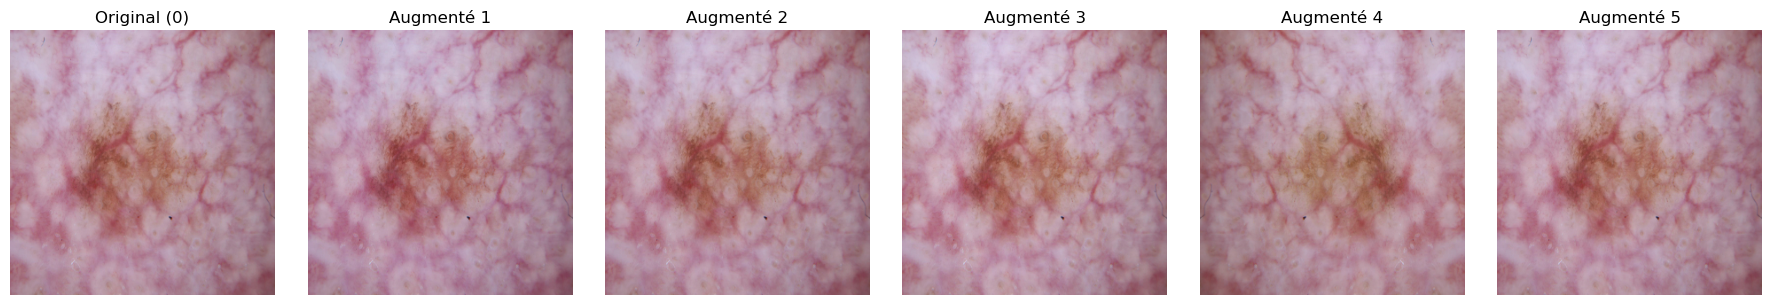

In [36]:
# Choisir une image "akiec" par ex
row = train_df_balanced[train_df_balanced['label'] == '0'].sample(1).iloc[0]
visualize_multiple_augmentations(row['path'], row['label'], augmenter, num_augments=5)


In [ ]:
val_ds = TargetedAugmentDataset(
    dataframe=val_df,
    img_size=(299, 299),
    class_names=class_names,
    batch_size=32,
    augment=False
).get_dataset()

In [2]:
val_ds = TargetedAugmentDataset(
    dataframe=val_df,
    img_size=(299, 299),
    class_names=class_names,
    batch_size=32,
    augment=False
).get_dataset()

NameError: name 'TargetedAugmentDataset' is not defined

In [22]:
optimizer = AdamW(learning_rate=5e-4,
                  weight_decay = 1e-3)


model.compile(
    optimizer=optimizer,
    #loss= 'categorical_crossentropy',  # Focal loss personnalisée
    loss = focal_loss(alpha=alpha, gamma=2.),
    metrics=[
        'accuracy',
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc')
    ]
)

In [15]:

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

CHECKPOINT_AUC = 'Protocole-S-V4-Xception-Akiec14-valAUC.keras'
CHECKPOINT_ACC = 'Protocole-S-V4-Xception-Akiec14-valACC.keras'

callbacks = [
    # Early stopping sur val_auc (objectif principal)
    EarlyStopping(
        monitor='val_accuracy',
        patience=6,
        restore_best_weights=True,
        verbose=1,
        mode='max',

    ),

    # Sauvegarde du meilleur modèle basé sur val_auc
    ModelCheckpoint(
        filepath=CHECKPOINT_AUC,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Sauvegarde secondaire sur val_accuracy
    ModelCheckpoint(
        filepath=CHECKPOINT_ACC,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),

    # Réduction du learning rate sur stagnation du val_auc
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.7,
        patience=2,
        min_lr=1e-6,
        min_delta=1e-4,
        mode='max',
        verbose=1
    ),
]


In [23]:
# 3. Continuer l'entraînement
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    initial_epoch=0,
    callbacks=callbacks,
    #class_weight=class_weight,
    verbose=1
)

Epoch 1/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 687ms/step - accuracy: 0.9077 - auc: 0.9939 - loss: 0.1383 - precision: 0.9372 - recall: 0.8780
Epoch 1: val_auc improved from 0.96233 to 0.96423, saving model to Protocole-S-V4-Xception-AkiecSeptember-valAUC.keras

Epoch 1: val_accuracy improved from 0.77922 to 0.79021, saving model to Protocole-S-V4-Xception-AkiecSeptember-valACC.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 180s 730ms/step - accuracy: 0.9058 - auc: 0.9935 - loss: 0.1538 - precision: 0.9336 - recall: 0.8743 - val_accuracy: 0.7902 - val_auc: 0.9642 - val_loss: 0.6973 - val_precision: 0.8410 - val_recall: 0.7293 - learning_rate: 5.0000e-04
Epoch 2/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 668ms/step - accuracy: 0.9114 - auc: 0.9938 - loss: 0.1495 - precision: 0.9405 - recall: 0.8837
Epoch 2: val_auc did not improve from 0.96423

Epoch 2: val_accuracy did not improve from 0.79021
243/243 ━━━━━━━━━━━━━━━━━━━━ 170s 699ms/step - accuracy: 0.9084 - auc: 0.9933 - loss: 0.1610 - precision: 0.9370 - re

KeyboardInterrupt: 

In [24]:
# 3. Continuer l'entraînement
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    initial_epoch=0,
    callbacks=callbacks,
    #class_weight=class_weight,
    verbose=1
)

Epoch 1/50


2025-09-04 16:59:14.436763: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.5033 - auc: 0.7852 - loss: 2.9970 - precision: 0.5546 - recall: 0.4288
Epoch 1: val_auc improved from None to 0.91788, saving model to Protocole-S-V4-Xception-AkiecSeptember-valAUC.keras

Epoch 1: val_accuracy improved from None to 0.66733, saving model to Protocole-S-V4-Xception-AkiecSeptember-valACC.keras
309/309 ━━━━━━━━━━━━━━━━━━━━ 90s 281ms/step - accuracy: 0.5787 - auc: 0.8465 - loss: 1.8321 - precision: 0.6414 - recall: 0.4895 - val_accuracy: 0.6673 - val_auc: 0.9179 - val_loss: 0.8836 - val_precision: 0.7753 - val_recall: 0.5654 - learning_rate: 0.0010
Epoch 2/50
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.6913 - auc: 0.9291 - loss: 0.7454 - precision: 0.7709 - recall: 0.6017
Epoch 2: val_auc did not improve from 0.91788

Epoch 2: val_accuracy did not improve from 0.66733
309/309 ━━━━━━━━━━━━━━━━━━━━ 87s 279ms/step - accuracy: 0.7072 - auc: 0.9372 - loss: 0.6545 - precision: 0.7872 - recall: 0.6162 - val_accu

In [18]:

# 3. Continuer l'entraînement
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    initial_epoch=0,
    callbacks=callbacks,
    #class_weight=class_weight,
    verbose=1
)

Epoch 1/8


2025-09-05 21:17:31.723663: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 794ms/step - accuracy: 0.9961 - auc: 1.0000 - loss: 0.0076 - precision: 0.9964 - recall: 0.9959
Epoch 1: val_auc improved from None to 0.99111, saving model to Protocole-S-V4-Xception-Akiec10-valAUC.keras

Epoch 1: val_accuracy improved from None to 0.91908, saving model to Protocole-S-V4-Xception-Akiec10-valACC.keras
309/309 ━━━━━━━━━━━━━━━━━━━━ 264s 832ms/step - accuracy: 0.9968 - auc: 1.0000 - loss: 0.0065 - precision: 0.9971 - recall: 0.9966 - val_accuracy: 0.9191 - val_auc: 0.9911 - val_loss: 0.6413 - val_precision: 0.9228 - val_recall: 0.9191 - learning_rate: 1.0000e-05
Epoch 2/8
309/309 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.9987 - auc: 1.0000 - loss: 0.0029 - precision: 0.9987 - recall: 0.9985
Epoch 2: val_auc did not improve from 0.99111

Epoch 2: val_accuracy improved from 0.91908 to 0.92208, saving model to Protocole-S-V4-Xception-Akiec10-valACC.keras
309/309 ━━━━━━━━━━━━━━━━━━━━ 253s 820ms/step - accuracy: 0.9991 - auc: 1.0000 - los

In [74]:
# Vérification du nombre de couches dégelées
num_trainable = sum([layer.trainable for layer in model.layers])
print(f"Nombre total de couches dégelées : {num_trainable}")

Nombre total de couches dégelées : 3


In [39]:
class_names = sorted(train_df_balanced['label'].unique().tolist())

In [45]:
#Class Weight
import numpy as np
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'  # <-- focus ici
}
from sklearn.utils import class_weight

# Labels entiers pour train
y_train_int = train_df["label"].astype(int)

# Calcul auto
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Dictionnaire de poids par classe
class_weights = dict(enumerate(weights))


In [16]:
from tensorflow import keras
from tensorflow.keras import backend as K
import tensorflow as tf
from tensorflow.keras import mixed_precision
from tensorflow.keras import layers, Model, Input, optimizers, regularizers
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.layers import Dropout
from tensorflow.keras.metrics import Recall, Precision, AUC


from tensorflow.keras import backend as K
import gc
import tensorflow as tf

# 1. Vider la session Keras
K.clear_session()

# 2. Forcer le garbage collector Python
gc.collect()

# 3. (Optionnel) Réinitialiser la graine pour reproductibilité
tf.random.set_seed(42)

mixed_precision.set_global_policy('mixed_float16')

optimizer = optimizers.AdamW(
learning_rate=1.e-05,
    weight_decay=1e-3,
    beta_1=0.9,        # Par défaut, mais explicite
    beta_2=0.999,      # Un peu plus conservateur pour les classes rares
    epsilon=1e-7       # Plus strict pour la stabilité numérique
)

import tensorflow as tf
from tensorflow import keras

FINE_TUNE_AT = 0

# --- 1. Charger votre modèle existant ---
model_path = 'Protocole-S-V4-Xception-Akiec13-valAUC.keras'
model = keras.models.load_model(model_path, 
                                compile=False)

for layer in model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
for layer in model.layers[FINE_TUNE_AT:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False  # On gèle BN
    else:
        layer.trainable = True   # On dégèle convolutions


# 2. Recompiler avec les bons paramètres
model.compile(
    optimizer = optimizer,
    loss = focal_loss(alpha=alpha, gamma=1),
    #loss = "categorical_crossentropy",
    metrics=[
        'accuracy',
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc')
    ]
)




In [13]:
# Vérification du nombre de couches dégelées
num_trainable = sum([layer.trainable for layer in model.layers])
print(f"Nombre total de couches dégelées : {num_trainable}")

Nombre total de couches dégelées : 97


In [17]:
# 2. Recompiler avec les bons paramètres

optimizer = optimizers.AdamW(
    learning_rate=1.e-05,
    weight_decay=1e-3,  # Tu peux monter à 1e-3 si besoin
    #clipnorm=1.0
)


model.compile(
    optimizer = optimizer,
    loss = focal_loss(alpha=alpha, gamma=0.5),
    #loss = 'categorical_crossentropy',
    metrics=[
        'accuracy',
        Recall(name='recall'),
        Precision(name='precision'),
        AUC(name='auc')
    ]
)


In [18]:

# Préparation du fit avec tf.data.Dataset
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    initial_epoch=0,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


2025-09-05 23:49:37.733928: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 796ms/step - accuracy: 0.9997 - auc: 1.0000 - loss: 0.0029 - precision: 0.9997 - recall: 0.9996
Epoch 1: val_auc improved from None to 0.98493, saving model to Protocole-S-V4-Xception-Akiec14-valAUC.keras

Epoch 1: val_accuracy improved from None to 0.91608, saving model to Protocole-S-V4-Xception-Akiec14-valACC.keras
323/323 ━━━━━━━━━━━━━━━━━━━━ 276s 832ms/step - accuracy: 0.9995 - auc: 0.9999 - loss: 0.0034 - precision: 0.9995 - recall: 0.9994 - val_accuracy: 0.9161 - val_auc: 0.9849 - val_loss: 1.3040 - val_precision: 0.9178 - val_recall: 0.9141 - learning_rate: 1.0000e-05
Epoch 2/30
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 791ms/step - accuracy: 0.9996 - auc: 1.0000 - loss: 0.0038 - precision: 0.9996 - recall: 0.9995
Epoch 2: val_auc improved from 0.98493 to 0.98521, saving model to Protocole-S-V4-Xception-Akiec14-valAUC.keras

Epoch 2: val_accuracy improved from 0.91608 to 0.92707, saving model to Protocole-S-V4-Xception-Akiec14-valACC.keras
323/323 ━━━━━━━━

In [17]:

# Préparation du fit avec tf.data.Dataset
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    initial_epoch=0,
    callbacks=callbacks,
    verbose=1
)

/Users/eric/miniforge3/envs/SKINCARE/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50


2025-09-05 14:39:01.774683: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 799ms/step - accuracy: 0.9526 - auc: 0.9956 - loss: 0.1910 - precision: 0.9561 - recall: 0.9489
Epoch 1: val_auc improved from None to 0.97724, saving model to Protocole-S-V4-Xception-Akiec7-valAUC.keras

Epoch 1: val_accuracy improved from None to 0.85714, saving model to Protocole-S-V4-Xception-Akiec7-valACC.keras
243/243 ━━━━━━━━━━━━━━━━━━━━ 211s 846ms/step - accuracy: 0.9484 - auc: 0.9950 - loss: 0.1921 - precision: 0.9537 - recall: 0.9434 - val_accuracy: 0.8571 - val_auc: 0.9772 - val_loss: 0.8732 - val_precision: 0.8665 - val_recall: 0.8492 - learning_rate: 3.0000e-04
Epoch 2/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 0s 786ms/step - accuracy: 0.9779 - auc: 0.9988 - loss: 0.0570 - precision: 0.9816 - recall: 0.9761
Epoch 2: val_auc improved from 0.97724 to 0.98739, saving model to Protocole-S-V4-Xception-Akiec7-valAUC.keras

Epoch 2: val_accuracy improved from 0.85714 to 0.89211, saving model to Protocole-S-V4-Xception-Akiec7-valACC.keras
243/243 ━━━━━━━━━━━━

KeyboardInterrupt: 

In [20]:
for x, y in train_ds.take(1):
    print("X shape:", x.shape)
    print("Y shape:", y.shape)
    print("Unique labels in batch:", np.unique(np.argmax(y.numpy(), axis=1)))


X shape: (32, 299, 299, 3)
Y shape: (32, 7)
Unique labels in batch: [0 1 2 4 6]


2025-08-31 22:21:18.492280: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [34]:
#Class Weight

CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'  # <-- focus ici
}
from sklearn.utils import class_weight

# Labels entiers pour train
y_train_int = train_df["label"].astype(int)

# Calcul auto
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)

# Dictionnaire de poids par classe
class_weights = dict(enumerate(weights))

class_weights[0] *= 7
#class_weights[6] *= 3


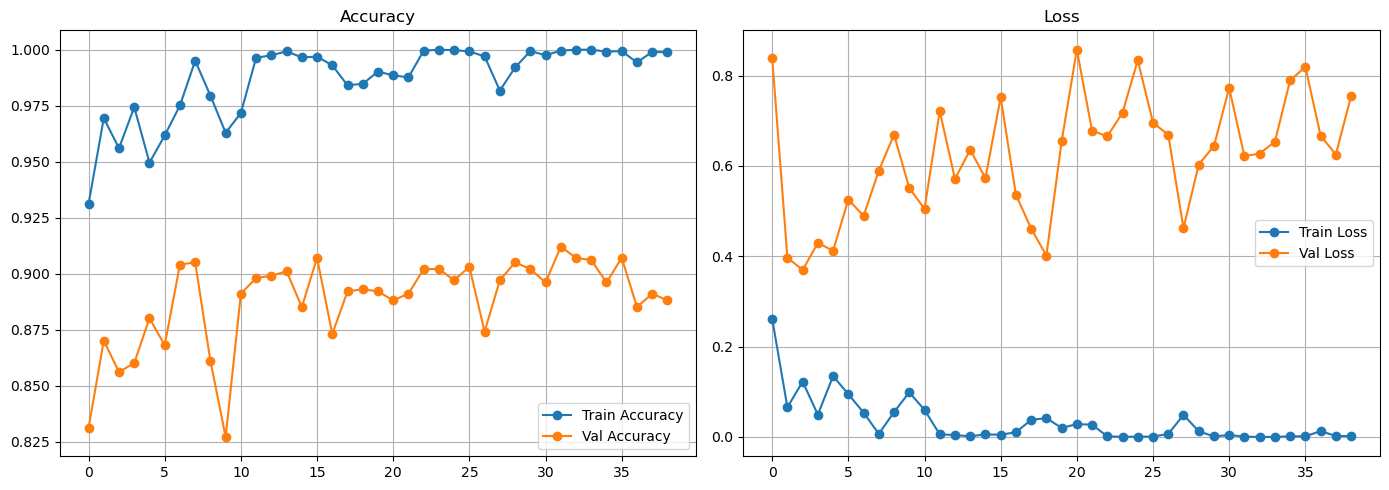

In [29]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # 🔹 Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', marker='o')
    plt.title('Accuracy')
    plt.legend()
    plt.grid(True)

    # 🔹 Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Val Loss', marker='o')
    plt.title('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ✅ Appel de la fonction après le fit
plot_training_history(history)

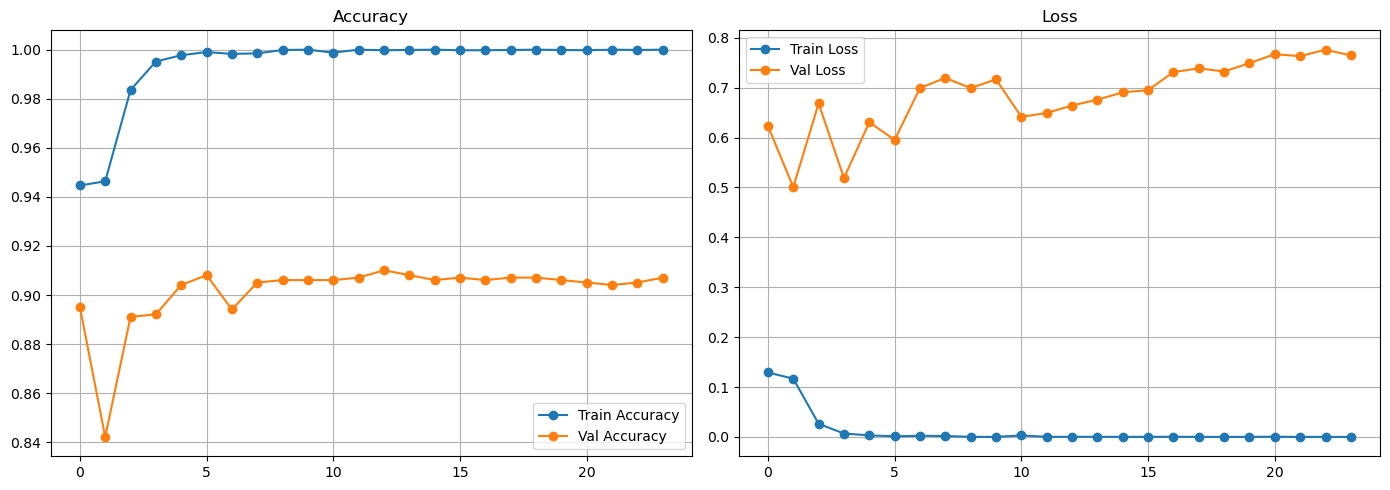

In [51]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    # 🔹 Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Train Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Val Accuracy', marker='o')
    plt.title('Accuracy')
    plt.legend()
    plt.grid(True)

    # 🔹 Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Train Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Val Loss', marker='o')
    plt.title('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# ✅ Appel de la fonction après le fit
plot_training_history(history)

Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 264ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_4285/1519814059.py:57: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/SKINCARE/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


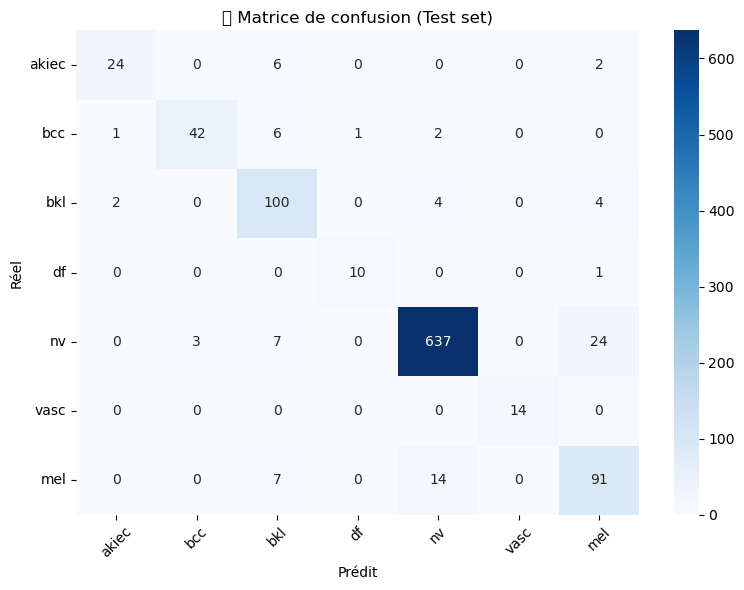


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.89      0.75      0.81        32
         bcc       0.93      0.81      0.87        52
         bkl       0.79      0.91      0.85       110
          df       0.91      0.91      0.91        11
          nv       0.97      0.95      0.96       671
        vasc       1.00      1.00      1.00        14
         mel       0.75      0.81      0.78       112

    accuracy                           0.92      1002
   macro avg       0.89      0.88      0.88      1002
weighted avg       0.92      0.92      0.92      1002



In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (299, 299)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))


Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 278ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_1918/1519814059.py:57: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


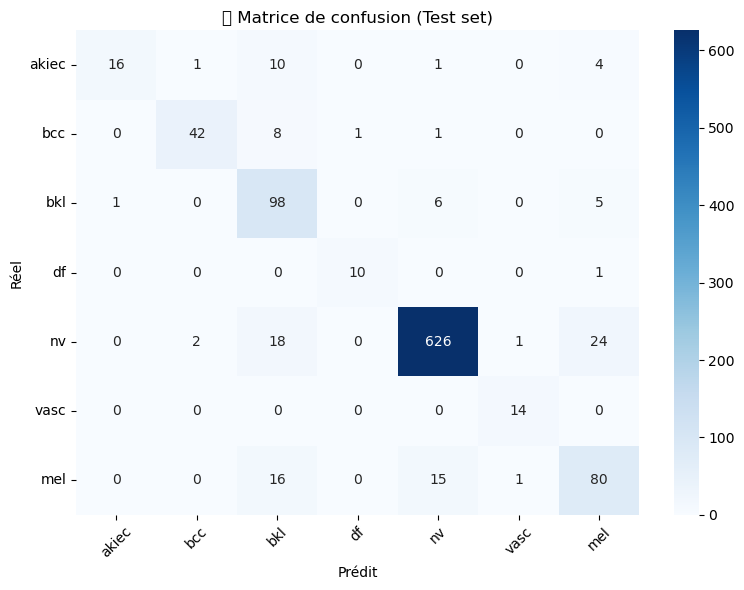


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.94      0.50      0.65        32
         bcc       0.93      0.81      0.87        52
         bkl       0.65      0.89      0.75       110
          df       0.91      0.91      0.91        11
          nv       0.96      0.93      0.95       671
        vasc       0.88      1.00      0.93        14
         mel       0.70      0.71      0.71       112

    accuracy                           0.88      1002
   macro avg       0.85      0.82      0.82      1002
weighted avg       0.90      0.88      0.89      1002



In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (299, 299)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))


Chargement des images du jeu de test...
Prédiction du modèle...
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step
Génération de la matrice de confusion...


/var/folders/jj/3s72m7nx3039djzxqt_p86w80000gn/T/ipykernel_1127/1549519804.py:57: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/eric/miniforge3/envs/tf-vit/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


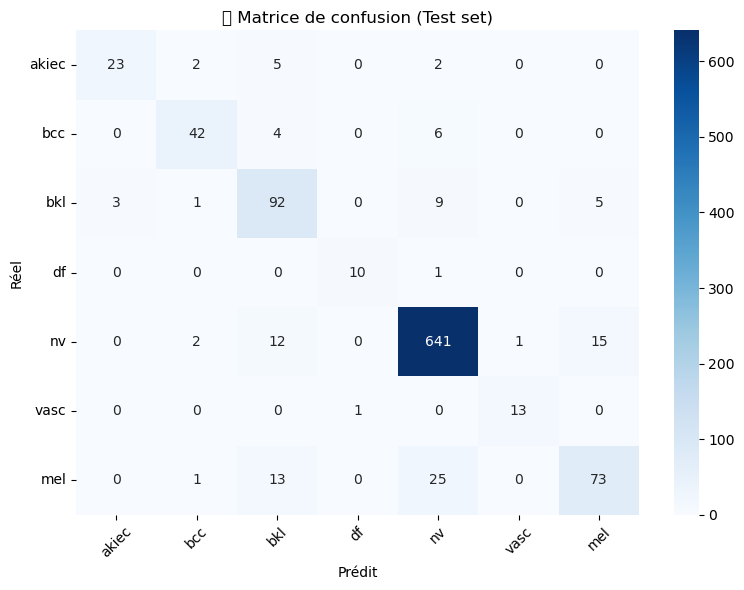


📄 Rapport de classification :

              precision    recall  f1-score   support

       akiec       0.88      0.72      0.79        32
         bcc       0.88      0.81      0.84        52
         bkl       0.73      0.84      0.78       110
          df       0.91      0.91      0.91        11
          nv       0.94      0.96      0.95       671
        vasc       0.93      0.93      0.93        14
         mel       0.78      0.65      0.71       112

    accuracy                           0.89      1002
   macro avg       0.86      0.83      0.84      1002
weighted avg       0.89      0.89      0.89      1002



In [102]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input

# === 🏷️ Labels et descriptions ===
CLASS_LABELS = {
    0: 'akiec',
    1: 'bcc',
    2: 'bkl',
    3: 'df',
    4: 'nv',
    5: 'vasc',
    6: 'mel'
}

# 📐 Taille des images attendue par le modèle (à adapter si besoin)
IMG_SIZE = (299, 299)


# 🧼 Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array  # Retourne un batch de 1


# 📥 Chargement des images de test
print("Chargement des images du jeu de test...")
X_test = np.array([preprocess_image(p) for p in test_df['path']])
y_test = test_df['label'].values

y_test = y_test.astype(int)

# 🤖 Prédictions
print("Prédiction du modèle...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)

# 📊 Matrice de confusion
print("Génération de la matrice de confusion...")
cm = confusion_matrix(y_test, y_pred)
labels = list(CLASS_LABELS.values())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('📉 Matrice de confusion (Test set)')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 🧾 Rapport classification (precision, recall, F1-score)
print("\n📄 Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=labels))


In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_gen.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


NameError: name 'test_gen' is not defined

/Users/eric/miniforge3/envs/SKINCARE/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 274ms/step


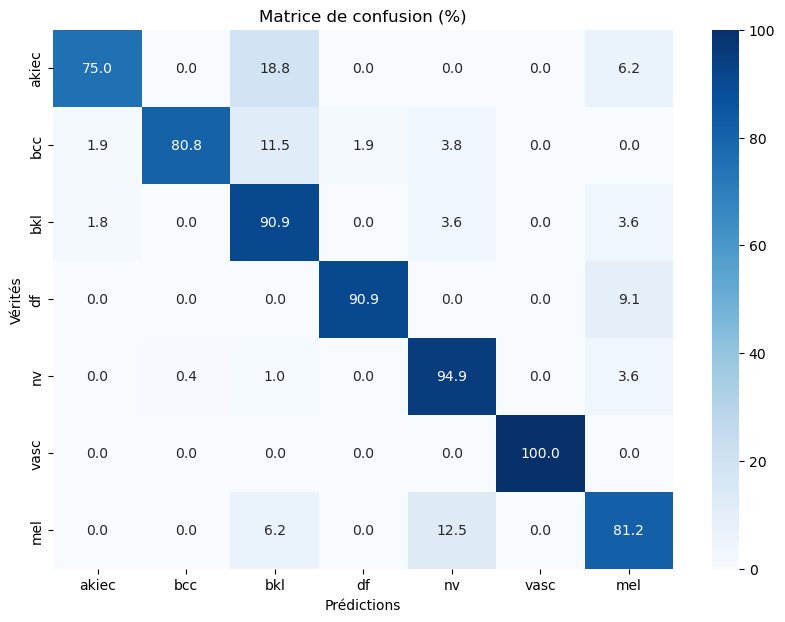

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


NameError: name 'test_generator' is not defined

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


NameError: name 'test_generator' is not defined

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = test_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


NameError: name 'test_generator' is not defined

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 271ms/step


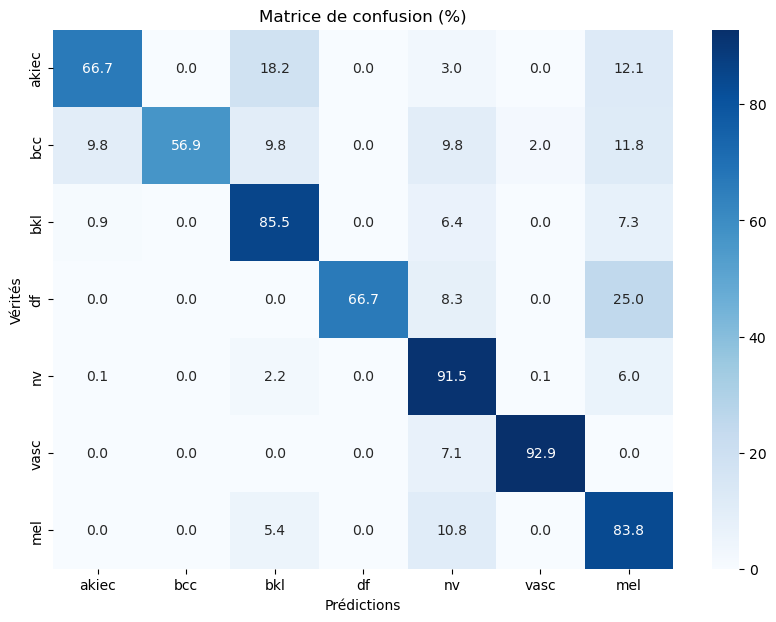

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = val_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()


32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 279ms/step


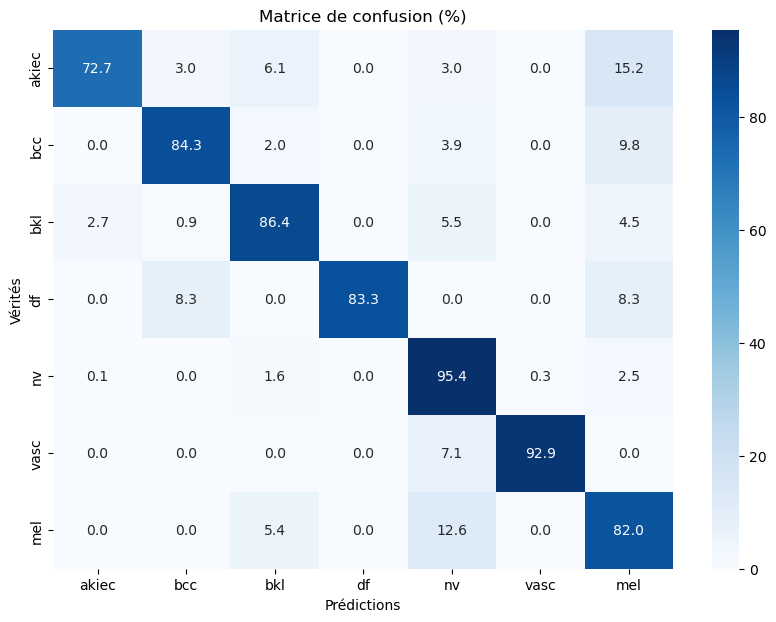

In [159]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 🔍 Prédictions
y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# 🎯 Vérités terrain
y_true = val_generator.classes

# 🧮 Matrice de confusion brute
cm = confusion_matrix(y_true, y_pred)

# ➗ Matrice de confusion en %
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# 📊 Affichage
plt.figure(figsize=(10, 7))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', xticklabels=CLASS_LABELS.values(), yticklabels=CLASS_LABELS.values())
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion (%)")
plt.show()




In [21]:
from tensorflow.keras.utils import register_keras_serializable
from tensorflow.keras.layers import Layer
from tensorflow.keras import backend as K

@register_keras_serializable()
class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.attention_weights = self.add_weight(
            name='attention_weights',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True,
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        score = K.dot(inputs, self.attention_weights)
        weights = K.softmax(score, axis=1)
        context = weights * inputs
        return K.sum(context, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], input_shape[-1])


In [25]:
model_loaded = load_model("Xception-Attention.keras", compile=False, custom_objects={"SimpleAttention": SimpleAttention})
# Trouvez le nom de votre couche base_model (Xception) dans model_loaded.summary()
# Supposons que son nom soit 'xception'
xception_layer_loaded = model_loaded.get_layer('xception') # Remplacez 'xception' par le vrai nom
print("Output shape of loaded Xception:", xception_layer_loaded.output_shape)

ValueError: Input 0 of layer "global_average_pooling2d" is incompatible with the layer: expected ndim=4, found ndim=3. Full shape received: (None, 10, 2048)

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.layers import Layer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import tensorflow as tf

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# Exemple d'une classe d'attention correctement sérialisable
@tf.keras.utils.register_keras_serializable()
class SimpleAttention(Layer):
    def __init__(self, **kwargs):
        super(SimpleAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.attention_weights = self.add_weight(
            name='att_weights',
            shape=(input_shape[-1], 1),
            initializer='random_normal',
            trainable=True
        )
        super(SimpleAttention, self).build(input_shape)

    def call(self, inputs):
        # Simple attention via softmax over dense projection
        scores = tf.matmul(inputs, self.attention_weights)
        weights = tf.nn.softmax(scores, axis=1)
        output = tf.reduce_sum(inputs * weights, axis=1)
        return output

# ⬇️ Charger tes données
# ⚠️ Assure-toi que test_df est défini (ex: par lecture d’un CSV avant ce point)
# test_df = pd.read_csv('ton_fichier.csv')
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle avec la custom layer
model = load_model("Xception-Attention.keras", compile=False, custom_objects={"SimpleAttention": SimpleAttention})


# 5. Prétraitement d'image
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 8. Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 9. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 10. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


ValueError: Input 0 of layer "global_average_pooling2d" is incompatible with the layer: expected ndim=4, found ndim=3. Full shape received: (None, 10, 2048)

2025-06-21 15:30:16.688036: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 260ms/step


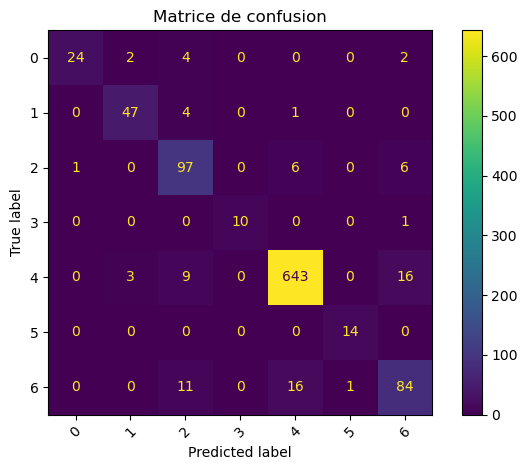

Rapport de classification :
              precision    recall  f1-score   support

           0       0.96      0.75      0.84        32
           1       0.90      0.90      0.90        52
           2       0.78      0.88      0.83       110
           3       1.00      0.91      0.95        11
           4       0.97      0.96      0.96       671
           5       0.93      1.00      0.97        14
           6       0.77      0.75      0.76       112

    accuracy                           0.92      1002
   macro avg       0.90      0.88      0.89      1002
weighted avg       0.92      0.92      0.92      1002



In [14]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-Xception-phaseSansTAG-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 270ms/step


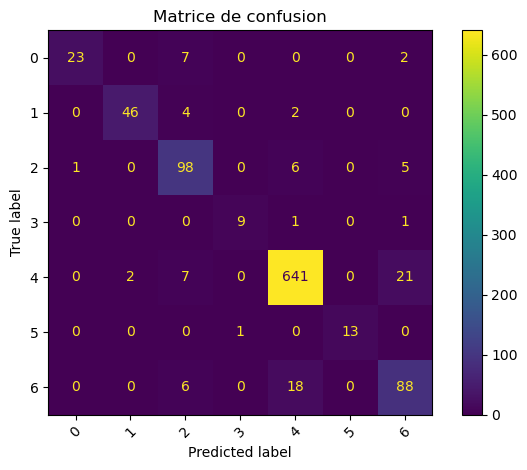

Rapport de classification :
              precision    recall  f1-score   support

           0       0.96      0.72      0.82        32
           1       0.96      0.88      0.92        52
           2       0.80      0.89      0.84       110
           3       0.90      0.82      0.86        11
           4       0.96      0.96      0.96       671
           5       1.00      0.93      0.96        14
           6       0.75      0.79      0.77       112

    accuracy                           0.92      1002
   macro avg       0.90      0.85      0.88      1002
weighted avg       0.92      0.92      0.92      1002



In [48]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V4-Xception-Akiec2-valAUC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 198ms/step


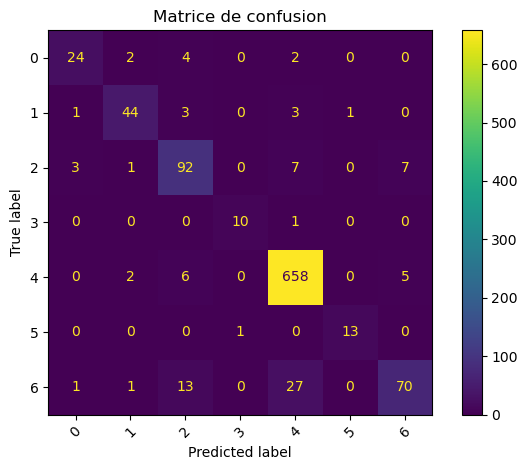

Rapport de classification :
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        32
           1       0.88      0.85      0.86        52
           2       0.78      0.84      0.81       110
           3       0.91      0.91      0.91        11
           4       0.94      0.98      0.96       671
           5       0.93      0.93      0.93        14
           6       0.85      0.62      0.72       112

    accuracy                           0.91      1002
   macro avg       0.87      0.84      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [6]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-InceptionV3-phase13-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


2025-06-21 10:26:56.930182: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-06-21 10:26:56.930220: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-06-21 10:26:56.930224: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1750494416.930245  146077 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1750494416.930275  146077 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-06-21 10:27:03.085812: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 262ms/step


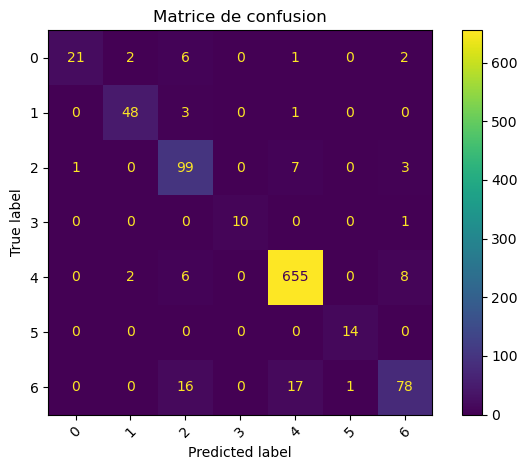

Rapport de classification :
              precision    recall  f1-score   support

           0       0.95      0.66      0.78        32
           1       0.92      0.92      0.92        52
           2       0.76      0.90      0.82       110
           3       1.00      0.91      0.95        11
           4       0.96      0.98      0.97       671
           5       0.93      1.00      0.97        14
           6       0.85      0.70      0.76       112

    accuracy                           0.92      1002
   macro avg       0.91      0.87      0.88      1002
weighted avg       0.92      0.92      0.92      1002



In [10]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V2-Xception-phase9-valACC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 285ms/step


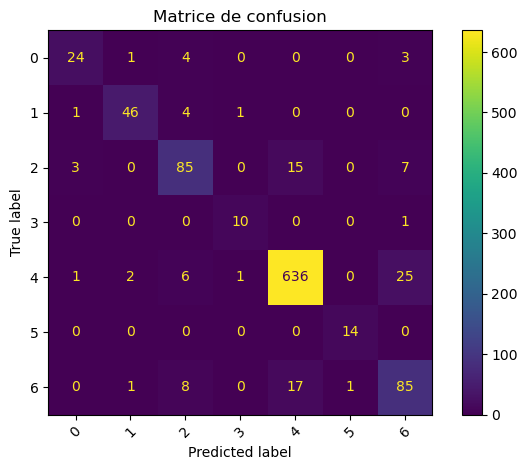

Rapport de classification :
              precision    recall  f1-score   support

           0       0.83      0.75      0.79        32
           1       0.92      0.88      0.90        52
           2       0.79      0.77      0.78       110
           3       0.83      0.91      0.87        11
           4       0.95      0.95      0.95       671
           5       0.93      1.00      0.97        14
           6       0.70      0.76      0.73       112

    accuracy                           0.90      1002
   macro avg       0.85      0.86      0.86      1002
weighted avg       0.90      0.90      0.90      1002



In [30]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V4-Xception-Akiec2-BEST.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step


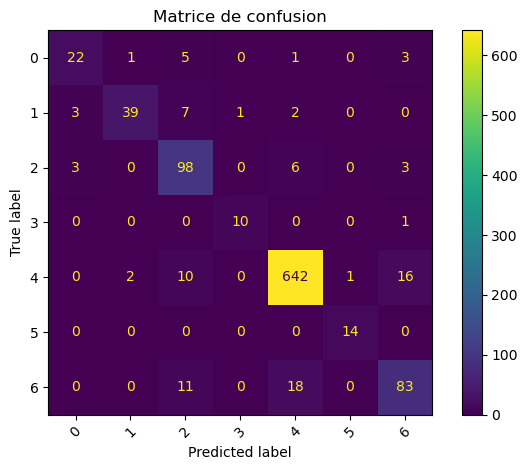

Rapport de classification :
              precision    recall  f1-score   support

           0       0.79      0.69      0.73        32
           1       0.93      0.75      0.83        52
           2       0.75      0.89      0.81       110
           3       0.91      0.91      0.91        11
           4       0.96      0.96      0.96       671
           5       0.93      1.00      0.97        14
           6       0.78      0.74      0.76       112

    accuracy                           0.91      1002
   macro avg       0.86      0.85      0.85      1002
weighted avg       0.91      0.91      0.91      1002



In [22]:
import json
import pandas as pd
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.xception import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📐 Taille d'image attendue par le modèle
IMG_SIZE = (299, 299)

# 1. Charger le DataFrame (à adapter selon ton cas réel)
# df = pd.read_csv("chemin/vers/ton_fichier.csv")  # Exemple

# 2. Charger les indices du jeu de test
##with open('split_indices.json', 'r') as f:
 #   split_indices = json.load(f)

#test_indices = split_indices['test']

# 3. Extraire les données de test
#test_df = df.loc[test_indices].copy()  # .copy() pour éviter SettingWithCopyWarning
test_df['label'] = test_df['label'].astype(str)

# 4. Charger le modèle
model = load_model('Protocole-S-V4-Xception-Akiec9-valAUC.keras', compile=False)

# 5. Fonction de prétraitement
def preprocess_image(path, target_size=IMG_SIZE):
    img = load_img(path, target_size=target_size)
    img_array = img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

# Fonction pour appliquer à toutes les images
def preprocess_images(paths):
    return np.array([preprocess_image(p) for p in paths])

# 6. Préparer les données
X_test = preprocess_images(test_df['path'])
y_true = test_df['label'].values

# 7. Prédictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Encodage des labels texte → entiers
class_indices = sorted(test_df['label'].unique())
label_to_index = {label: i for i, label in enumerate(class_indices)}
index_to_label = {i: label for label, i in label_to_index.items()}
y_true_encoded = np.array([label_to_index[label] for label in y_true])

# 8. Matrice de confusion
cm = confusion_matrix(y_true_encoded, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_indices)
disp.plot(xticks_rotation=45)
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

# 9. Rapport de classification
print("Rapport de classification :")
print(classification_report(y_true_encoded, y_pred, target_names=class_indices))


In [25]:
import tensorflow as tf
import numpy as np

class AdvancedTargetedAugmentDataset:
    def __init__(self, dataframe, img_size, class_names, batch_size=32, augment=True, akiec_boost=2):
        self.df = dataframe.reset_index(drop=True)
        self.img_size = img_size
        self.class_names = list(class_names)
        self.batch_size = batch_size
        self.augment = augment
        self.akiec_boost = akiec_boost

        # Table de lookup pour l'encodage des labels
        self.label_lookup = tf.lookup.StaticHashTable(
            tf.lookup.KeyValueTensorInitializer(
                keys=tf.constant(self.class_names),
                values=tf.constant(list(range(len(self.class_names))), dtype=tf.int32)
            ),
            default_value=-1
        )

    def get_dataset(self):
        # Sur-échantillonnage AKIEC AVANT la création du dataset
        df_processed = self._oversample_akiec()
        
        paths = df_processed['path'].values
        labels = df_processed['label'].values
        
        dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
        if self.augment:
            dataset = dataset.shuffle(buffer_size=len(paths))
        dataset = dataset.map(self.process_example, num_parallel_calls=tf.data.AUTOTUNE)
        dataset = dataset.batch(self.batch_size).prefetch(tf.data.AUTOTUNE)
        return dataset

    def _oversample_akiec(self):
        """Sur-échantillonne la classe AKIEC selon akiec_boost"""
        if not self.augment or self.akiec_boost <= 1:
            return self.df
        
        akiec_samples = self.df[self.df['label'] == 'akiec']
        other_samples = self.df[self.df['label'] != 'akiec']
        
        # Répliquer les échantillons AKIEC
        akiec_boosted = []
        for _ in range(self.akiec_boost):
            akiec_boosted.append(akiec_samples)
        
        df_boosted = pd.concat([other_samples] + akiec_boosted, ignore_index=True)
        return df_boosted.sample(frac=1).reset_index(drop=True)  # Mélanger

    def load_image(self, path):
        path = tf.convert_to_tensor(path, dtype=tf.string)
        img_raw = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img_raw, channels=3)
        img = tf.image.convert_image_dtype(img, tf.float32)
        img = tf.image.resize(img, self.img_size)
        return img

    def encode_label(self, label):
        index = self.label_lookup.lookup(label)
        return tf.one_hot(index, depth=len(self.class_names))

    def process_example(self, path, label):
        label = tf.convert_to_tensor(label, dtype=tf.string)
        img = self.load_image(path)
        one_hot = self.encode_label(label)

        if self.augment:
            # Augmentation ciblée AKIEC (plus modérée)
            akiec_mask = tf.equal(label, 'akiec')

            def akiec_aug(): return self.akiec_moderate_augmentation(img)
            def standard_aug(): return self.standard_augmentation(img)

            img = tf.cond(akiec_mask, akiec_aug, standard_aug)

        return img, one_hot

    def akiec_moderate_augmentation(self, img):
        """Augmentations modérées pour préserver les caractéristiques diagnostiques"""
        # Flips (gardent la structure)
        img = tf.image.random_flip_left_right(img)
        if tf.random.uniform([]) > 0.7:  # Moins fréquent
            img = tf.image.random_flip_up_down(img)

        # Rotations légères seulement (pas 90°/180°/270°)
        angle = tf.random.uniform([], -15, 15) * 3.14159 / 180  # ±15 degrés
        img = tfa.image.rotate(img, angle) if 'tfa' in globals() else img
        
        # Ajustements colorimétriques modérés
        img = tf.image.random_brightness(img, 0.1)  # Réduit de 0.15 à 0.1
        img = tf.image.random_contrast(img, 0.9, 1.1)  # Réduit
        img = tf.image.random_saturation(img, 0.9, 1.1)  # Réduit
        img = tf.image.random_hue(img, 0.02)  # Réduit de 0.05 à 0.02

        # Crop plus conservateur
        crop_frac = tf.random.uniform([], 0.9, 1.0)  # 90-100% au lieu de 75-100%
        new_size = tf.cast(crop_frac * tf.cast(self.img_size[0], tf.float32), tf.int32)
        img = tf.image.resize_with_crop_or_pad(img, new_size, new_size)
        img = tf.image.resize(img, self.img_size)

        # Cutout plus petit et occasionnel
        if tf.random.uniform([]) > 0.7:  # Seulement 30% du temps
            img = self._apply_cutout(img, cutout_ratio=0.1)  # 10% au lieu de 20%

        img = tf.clip_by_value(img, 0.0, 1.0)
        return img

    def _apply_cutout(self, img, cutout_ratio=0.1):
        """Cutout plus petit et mieux contrôlé"""
        h, w = self.img_size
        cy = tf.random.uniform([], 0, h, dtype=tf.int32)
        cx = tf.random.uniform([], 0, w, dtype=tf.int32)
        
        size = tf.cast(cutout_ratio * h, tf.int32)
        y1 = tf.maximum(0, cy - size // 2)
        y2 = tf.minimum(h, cy + size // 2)
        x1 = tf.maximum(0, cx - size // 2)
        x2 = tf.minimum(w, cx + size // 2)
        
        # Créer le masque de cutout
        indices = tf.stack(tf.meshgrid(tf.range(y1, y2), tf.range(x1, x2), indexing='ij'), axis=-1)
        indices = tf.reshape(indices, [-1, 2])
        
        mask = tf.ones([h, w, 3], dtype=tf.float32)
        updates = tf.zeros([tf.shape(indices)[0], 3])
        mask = tf.tensor_scatter_nd_update(mask, indices, updates)
        
        return img * mask

    def standard_augmentation(self, img):
        """Augmentations standard pour les autres classes"""
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.05)
        img = tf.image.random_contrast(img, 0.95, 1.05)
        
        # Crop léger occasionnel
        if tf.random.uniform([]) > 0.8:
            crop_frac = tf.random.uniform([], 0.95, 1.0)
            new_size = tf.cast(crop_frac * tf.cast(self.img_size[0], tf.float32), tf.int32)
            img = tf.image.resize_with_crop_or_pad(img, new_size, new_size)
            img = tf.image.resize(img, self.img_size)
        
        img = tf.clip_by_value(img, 0.0, 1.0)
        return img

# Utilisation avec vérification des distributions
def analyze_class_distribution(dataset, class_names, num_batches=50):
    """Analyse la distribution des classes dans le dataset"""
    class_counts = np.zeros(len(class_names))
    
    for i, (images, labels) in enumerate(dataset.take(num_batches)):
        class_indices = tf.argmax(labels, axis=1).numpy()
        for idx in class_indices:
            class_counts[idx] += 1
    
    for i, class_name in enumerate(class_names):
        print(f"{class_name}: {class_counts[i]:.0f} échantillons")
    
    return class_counts

# Exemple d'utilisation
class_names = sorted(train_df['label'].unique().tolist())

print("=== AVANT AUGMENTATION ===")
print("Distribution originale:")
original_counts = train_df['label'].value_counts()
total_original = len(train_df)
for class_name in class_names:
    count = original_counts.get(class_name, 0)
    percentage = (count / total_original) * 100
    print(f"{class_name}: {count} échantillons ({percentage:.1f}%)")

print(f"\nMapping des classes:")
for i, class_name in enumerate(class_names):
    print(f"{i}: {class_name}")

# Train avec augmentations ciblées corrigées
train_aug = AdvancedTargetedAugmentDataset(
    train_df_balanced,
    img_size=(299, 299),
    class_names=class_names,
    batch_size=32,
    augment=True,
    akiec_boost=3  # Boost modéré
)
train_ds = train_aug.get_dataset()

print("\n=== APRÈS AUGMENTATION ===")
analyze_class_distribution(train_ds, class_names, num_batches=100)  # Plus de batches pour plus de précision

# Validation sans augmentation
val_aug = AdvancedTargetedAugmentDataset(
    val_df,
    img_size=(299, 299),
    class_names=class_names,
    batch_size=32,
    augment=False
)
val_ds = val_aug.get_dataset()

=== AVANT AUGMENTATION ===
Distribution originale:
0: 262 échantillons (3.3%)
1: 411 échantillons (5.1%)
2: 879 échantillons (11.0%)
3: 92 échantillons (1.1%)
4: 5364 échantillons (66.9%)
5: 114 échantillons (1.4%)
6: 890 échantillons (11.1%)

Mapping des classes:
0: 0
1: 1
2: 2
3: 3
4: 4
5: 5
6: 6

=== APRÈS AUGMENTATION ===
0: 568 échantillons
1: 133 échantillons
2: 312 échantillons
3: 39 échantillons
4: 1788 échantillons
5: 38 échantillons
6: 322 échantillons


2025-09-05 08:53:59.518698: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
